# Project Introduction [sentiment]

## Project Overview
This notebook implements an end-to-end machine learning workflow for **sentiment analysis from tweets**. It unifies data preparation, exploratory analysis, classical baselines, static-embedding neural models, and transformer fine-tuning in a single reproducible experiment pipeline.

The dataset is structured around two primary data fields: a text feature containing string data and a label feature for multi-class emotion classification. This label categorizes entries into six distinct emotional states: sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5). The dataset has 416,809 observations contained within a single training split.

## Objectives
- Establish reliable baselines and progressively stronger models under a shared train/validation/test protocol.
- Compare model families consistently using accuracy, macro/weighted F1, confusion matrices, and learning curves.
- Track experiment outputs (checkpoints, logs, plots, metrics) for reproducible analysis and reporting.
- Provide one configurable notebook for both full reruns and targeted experimentation.

## Table of Contents
- [SECTION 0 — Environment Setup & Reproducibility](#section-0-environment-setup-reproducibility)
- [SECTION 1 — Utility Functions & Helper Classes](#section-1-utility-functions-helper-classes)
    - [1.1 Core Constants & Plot Display Helper](#11-core-constants-plot-display-helper)
    - [1.2 Text Preprocessing Helpers](#12-text-preprocessing-helpers)
    - [1.3 EDA Text Feature Helpers](#13-eda-text-feature-helpers)
    - [1.4 Evaluation, I/O, Splitting, and Model Utilities](#14-evaluation-i-o-splitting-and-model-utilities)
    - [1.5 Embedding & Sequence Utilities](#15-embedding-sequence-utilities)
    - [1.6 Deep Experiment Runner Utilities](#16-deep-experiment-runner-utilities)
    - [1.7 Transformer Utilities](#17-transformer-utilities)
    - [1.8 Training Utilities (Shared Deep Learning Loop)](#18-training-utilities-shared-deep-learning-loop)
    - [1.9 Utility Registry Summary](#19-utility-registry-summary)
- [SECTION 2 — Data Loading & Inspection](#section-2-data-loading-inspection)
- [SECTION 3 — Data preparation](#section-3-preprocessing)
  - [Preprocessing steps](#preprocessing-steps)
  - [Train/Val/Test split](#section-3-train-val-test-split)
- [SECTION 5 — Baseline Models](#section-5-baseline-models)
  - [5.1 Preparation & Architecture](#51-preparation-architecture)
  - [5.3 Training](#53-training)
  - [5.4 Results](#54-results)
- [SECTION 6 — Static Embeddings + Models (FastText, MLP + CNN)](#section-6-static-embeddings-fasttext)
  - [6.1 Preparation & Architecture](#61-preparation-architecture)
  - [6.3 Training](#63-training)
  - [6.4 Results](#64-results)
- [SECTION 7 — Recurrent Models (BiLSTM / BiGRU)](#section-7-recurrent-models-bilstm-bigru)
  - [7.1 Preparation & Architecture](#71-preparation-architecture)
  - [7.3 Training](#73-training)
  - [7.4 Results](#74-results)
- [SECTION 11 — Transformer Fine-Tuning](#section-11-transformer-fine-tuning)
  - [11.1 Preparation & Architecture](#111-preparation-architecture)
  - [11.3 Training](#113-training)
    - [11.3.1 DistilBERT_500k](#1131-distilbert-500k)
    - [11.3.2 RoBERTa_500k](#1132-roberta-500k)
    - [11.3.3 DistilBERT_1000k](#1133-distilbert-1000k)
  - [11.4 Results](#114-results)
- [SECTION 12 — Model Comparison & Results Table](#section-12-model-comparison-results-table)
- [SECTION 13 — Saving, Logging & Final Report](#section-13-saving-logging-final-report)

## Notebook Usage Modes
1. **Full pipeline run**
   - Set `CFG["run_data_prep"] = True`, then execute top-to-bottom to rebuild splits and refresh all downstream artifacts.
2. **Evaluation/cached-artifact run**
   - Keep `CFG["run_data_prep"] = False` to reuse stored splits and existing model artifacts.
   - For transformer runs, set `CFG["run_transformer_eval"] = False` to load cached metrics/predictions when available.
3. **Experimentation mode**
   - Modify selected `CFG` entries (for example n-grams, embeddings, model hyperparameters, transformer choice) and rerun only relevant sections.
4. **Transformer-focused run**
   - Run Section 11 once preprocessing/splits are available, then iterate primarily on `trf_model`, `batch_size`, `epochs`, and `lr`.

## Important Notes
- **Dependencies:** The notebook expects the Python ML stack used in Section 0 (`pandas`, `numpy`, `scikit-learn`, `xgboost`, `torch`, `transformers`, `gensim`, `nltk`, `duckdb`, and plotting libraries).
- **NLTK resources:** `stopwords`, `wordnet`, and `punkt` are requested at runtime; ensure internet access on first download.
- **Expected directories:** Inputs and artifacts are organized under `data/`, `models/`, `outputs/`, and `logs/`. Splits are loaded from `data/abcde/reddit/splits.pkl` when preprocessing is skipped.
- **Configuration behavior:** `CFG` in Section 0 is the single execution control point (paths, seed, task metadata, model/training settings, and run toggles).
- **Checkpoint caching:** Deep and transformer routines reuse existing best checkpoints when found and may skip retraining automatically.
- **Reproducibility:** `set_seed(CFG["seed"])` is applied; device selection is automatic (`mps`/`cuda`/`cpu`). Keep package versions and hardware consistent for strict run-to-run comparisons.
- **Section numbering:** Sections 8-10 are intentionally omitted in the current notebook sequence.


---
<a id="section-0-environment-setup-reproducibility"></a>
# SECTION 0 — Environment Setup & Reproducibility


In [4]:
pip install numpy pandas matplotlib seaborn scikit-learn nltk gensim transformers torch accelerate xgboost plotly jupyterlab ipywidgets duckdb

   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------- ----------------------- 5.0/12.3 MB 37.7 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 38.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
# TO USE MY GPU
!pip install torch --index-url https://download.pytorch.org/whl/cu121        # For CUDA use my own GPU CUDA 12.4 (RTX 4050)
!pip install d2l==1.0.0a1.post0


import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: No GPU detected. Check PyTorch.")

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


GPU detected: NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
# ── 0.1 Imports ─────────────────────────────────────────────────────────────

# Standard Library
import json
import logging
import os
import pickle
import random
import re
import shutil
import sys
import time
import unicodedata
import warnings
from collections import Counter
from datetime import datetime
from pathlib import Path

# Data / Visualization
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

# Database
import duckdb

# Sklearn
import joblib
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
    ParameterSampler,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.svm import LinearSVC

# XGBoost
from xgboost import XGBClassifier

# Deep learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

# Transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from transformers.trainer_utils import get_last_checkpoint

# Embeddings
import gensim.downloader as api

# NLP (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- Configuración Final ---
nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)

# Evita warnings de paralelismo en Tokenizers de Hugging Face
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

print("Imports OK") 

Imports OK


In [57]:
# ── 0.2 Global Configuration ─────────────────────────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir":   Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir":  Path("models/"),
    "log_dir":    Path("logs/"),

    # ── Task ────────────────────────────────────────────────────────────────
    # Options: sentiment_analysis | abuse_detection | age-classification | etc.
    "task":       "sentiment_analysis", 
    "text_col":   "text",
    "label_col":  "label",
    "num_labels": 7,

    # ── Notebook execution toggles (De la versión de tu compañero)
    "run_data_prep": True,
    "run_transformer_eval": False,

    # ── Split
    "test_size": 0.15,
    "val_size":  0.15,

    # ── Cross-validation
    "use_cv":    True,
    "cv_folds":  5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams":   True,
    "class_weight":      "balanced",

    # ── Embeddings (Valores optimizados)
    "embedding_model": "fasttext-wiki-news-subwords-300", 
    "embedding_dim":   300,
    "vocab_size":      50_000,
    "max_seq_len":     128,
    "pad_token":       "<PAD>",
    "unk_token":       "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs":     20,
    "dl_lr":         1e-3,
    "dl_patience":   3,
    "dropout":       0.3,

    # ── CNN-specific
    "cnn_num_filters":  128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer
    "trf_model":  "bert-base-uncased", # o "distilbert-base-uncased"
    "max_len":    256,
    "batch_size": 16,
    "epochs":     5,
    "lr":         2e-5,

    # ── Device    
    "device": (
        "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
}

# ── Sub-rutas de salida (Estructura organizada de tu compañero)
CFG["output_paths"] = {
    "eda":              CFG["output_dir"] / "eda",
    "metrics":          CFG["output_dir"] / "metrics",
    "runs":             CFG["output_dir"] / "runs",
    "plots_learning":   CFG["output_dir"] / "plots" / "learning_curves",
    "plots_confusion":  CFG["output_dir"] / "plots" / "confusion_matrices",
    "plots_history":    CFG["output_dir"] / "plots" / "training_curves",
    "plots_comparison": CFG["output_dir"] / "plots" / "comparisons",
}

# ── Creación automática de directorios
for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True)

for p in CFG["output_paths"].values():
    p.mkdir(parents=True, exist_ok=True)

print(f"Task    : {CFG['task']}")
print(f"Labels  : {CFG['num_labels']}")
print(f"Device  : {CFG['device']}")
print(f"Outputs : {CFG['output_dir']} (Subfolders ready)")

Task    : sentiment_analysis
Labels  : 7
Device  : cuda
Outputs : outputs (Subfolders ready)


In [7]:
# ── 0.3 def set_seed(seed: int = 42): ─────────────────────────────────────────
def set_seed(seed: int = 42):
    """Fix all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(CFG["seed"])
print("Seed set.")


Seed set.


---
<a id="section-1-utility-functions-helper-classes"></a>
# SECTION 1 — Utility Functions & Helper Classes

All shared functions/classes are defined here before first usage in data/splits/models sections.


### 1.1 Core Constants & Plot Display Helper


In [58]:
# ── 1.1 CLASSES  ─────────────────────────────────────────
CLASSES = ['0', '1', '2', '3', '4', '5', '6']
COLORS = ["#003366", "#0066CC",  "#1171D2", "#4DA6FF", "#99CCFF", "#CCE5FF", "#E2EFFB",]

sns.set_theme(style="whitegrid", palette=COLORS)
plt.rcParams["figure.dpi"] = 120


def display_saved_plot(plot_path: Path, title: str = None, figsize=(10, 6)) -> bool:
    plot_path = Path(plot_path)
    if not plot_path.exists():
        return False

    try:
        img = plt.imread(plot_path)
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img)
        ax.axis("off")
        if title:
            ax.set_title(title)
        plt.tight_layout()
        plt.show()
        return True
    except Exception as e:
        print(f"Could not display existing plot {plot_path}: {e}")
        return False


### 1.2 Text Preprocessing Helpers


In [59]:
# ── 1.2 STOP = set(stopwords.words("english")) ─────────────────────────────────────────
STOP = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def normalize_text(text: str) -> str:
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_from_normalized(text: str, remove_stopwords: bool = True, lemmatize: bool = True) -> str:
    text = text.lower()
    tokens = text.split()
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    return " ".join(tokens)


sample = "This is a GREAT movie!! http://example.com @user #review"
print("Raw         :", sample)
print("Normalized  :", normalize_text(sample))
print("Preprocessed:", preprocess_from_normalized(normalize_text(sample)))


Raw         : This is a GREAT movie!! http://example.com @user #review
Normalized  : This is a GREAT movie!!
Preprocessed: great movie!!


### 1.3 EDA Text Feature Helpers


In [93]:
# ── 1.3 from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS ─────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

EXTRA_STOPWORDS = globals().get("EXTRA_STOPWORDS", set())
CONSULTING_COLORS = globals().get("CONSULTING_COLORS", COLORS)

def clean_text_fallback(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def get_top_words_tfidf(df, cls, n=15):
    class_texts = {}
    
    temp_df = df.copy()
    temp_df["label"] = temp_df["label"].astype(str)

    for c in CLASSES:
        subset = temp_df[temp_df["label"] == str(c)]["text"]
        texts = subset.dropna().apply(clean_text_fallback).tolist()
        
        combined = " ".join(texts).strip()
        class_texts[str(c)] = combined if len(combined) > 0 else "empty_document_placeholder"

    all_docs = list(class_texts.values())
    all_labels = list(class_texts.keys())

    # Configuramos el vectorizador
    vec = TfidfVectorizer(
        stop_words=list(ENGLISH_STOP_WORDS.union(EXTRA_STOPWORDS)),
        max_features=10_000,
        ngram_range=(1, 1),
        min_df=1,
    )
    
    try:
        X = vec.fit_transform(all_docs)
        words = vec.get_feature_names_out()

        cls_idx = all_labels.index(str(cls))
        scores = X[cls_idx].toarray().flatten()
        
        if scores.sum() == 0:
            return pd.DataFrame(columns=["word", "score"])

        top = sorted(zip(words, scores), key=lambda x: -x[1])[:n]
        return pd.DataFrame(top, columns=["word", "score"])
    
    except ValueError:
        return pd.DataFrame(columns=["word", "score"])


### 1.4 Evaluation, I/O, Splitting, and Model Utilities


In [61]:
# ── 1.4 class DictLabelEncoder: ─────────────────────────────────────────
class DictLabelEncoder:
    def __init__(self, mapping: dict):
        first_key = next(iter(mapping))
        if isinstance(first_key, int):
            id2class = mapping
        else:
            id2class = {v: k for k, v in mapping.items()}
        self.classes_ = np.array([id2class[i] for i in sorted(id2class)])

    def inverse_transform(self, y):
        y_arr = np.asarray(y, dtype=np.int64)
        return np.array([self.classes_[i] if 0 <= i < len(self.classes_) else str(i) for i in y_arr])

    def transform(self, labels):
        class2id = {c: i for i, c in enumerate(self.classes_)}
        labels_arr = np.asarray(labels)
        return np.array([class2id[x] for x in labels_arr], dtype=np.int64)


In [ ]:
# ── 1.5 RESULTS = {} ─────────────────────────────────────────
RESULTS = {}


def slugify(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return re.sub(r"_+", "_", text).strip("_")


def now_ts() -> str:
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def size_tag_from_split(split_key: str) -> str:
    m = re.search(r"(\d+[km]?)$", split_key.lower())
    return m.group(1) if m else slugify(split_key)


def first_existing_path(*paths):
    for p in paths:
        if p is None:
            continue
        pp = Path(p)
        if pp.exists():
            return pp
    return None

def load_pickle_with_fallback(primary: Path, *fallbacks: Path):
    path = first_existing_path(primary, *fallbacks)
    if path is None:
        raise FileNotFoundError(f"Could not find pickle file. Tried: {[str(primary), *map(str, fallbacks)]}")
    with open(path, "rb") as f:
        obj = pickle.load(f)
    print(f"Loaded pickle: {path}")
    return obj

def load_csv_with_fallback(primary: Path, *fallbacks: Path) -> pd.DataFrame:
    path = first_existing_path(primary, *fallbacks)
    if path is None:
        raise FileNotFoundError(f"Could not find CSV file. Tried: {[str(primary), *map(str, fallbacks)]}")
    print(f"Loaded csv: {path}")
    return pd.read_csv(path)

def display_saved_plot(plot_path: Path, title: str = None, figsize=(10, 6)) -> bool:
    plot_path = Path(plot_path)
    if not plot_path.exists():
        return False

    try:
        img = plt.imread(plot_path)
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img)
        ax.axis("off")
        if title:
            ax.set_title(title)
        plt.tight_layout()
        plt.show()
        return True
    except Exception as e:
        print(f"Could not display existing plot {plot_path}: {e}")
        return False


def _link_or_copy_file(src: Path, dst: Path):
    src = Path(src)
    dst = Path(dst)
    if dst.exists() or not src.exists() or not src.is_file():
        return
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except Exception:
        shutil.copy2(src, dst)


def _link_or_copy_dir_contents(src_dir: Path, dst_dir: Path, include_pattern: str = None):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    if not src_dir.exists() or not src_dir.is_dir():
        return False

    dst_dir.mkdir(parents=True, exist_ok=True)
    if include_pattern is None:
        items = [p for p in src_dir.iterdir() if p.name != ".DS_Store"]
    else:
        items = [p for p in src_dir.glob(include_pattern)]

    copied_any = False
    for item in items:
        target = dst_dir / item.name
        if target.exists():
            copied_any = True
            continue
        try:
            if item.is_dir():
                os.symlink(item.resolve(), target, target_is_directory=True)
            else:
                os.symlink(item.resolve(), target)
        except Exception:
            if item.is_dir():
                shutil.copytree(item, target)
            else:
                shutil.copy2(item, target)
        copied_any = True

    return copied_any


def find_latest_experiment_dir(prefix: str, model_root: Path = None, require_best: bool = False):
    model_root = model_root or CFG["model_dir"]
    patt = re.compile(rf"^{re.escape(prefix)}_\d{{8}}_\d{{6}}$")
    candidates = [p for p in model_root.iterdir() if p.is_dir() and patt.match(p.name)]
    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda p: p.name)
    if not require_best:
        return candidates[-1]

    for cand in reversed(candidates):
        best_dir = cand / "best_model"
        if best_dir.exists() and any(best_dir.iterdir()):
            return cand
    return None


def resolve_experiment_paths(model_family: str, dataset: str, size_tag: str, model_root: Path = None) -> dict:
    model_root = model_root or CFG["model_dir"]
    prefix = f"{slugify(model_family)}_{slugify(dataset)}_{slugify(size_tag)}"

    exp_root = find_latest_experiment_dir(prefix, model_root=model_root, require_best=True)
    if exp_root is None:
        exp_root = find_latest_experiment_dir(prefix, model_root=model_root, require_best=False)
    if exp_root is None:
        exp_root = model_root / f"{prefix}_{now_ts()}"

    exp_root.mkdir(parents=True, exist_ok=True)
    paths = {
        "prefix": prefix,
        "root": exp_root,
        "best_model": exp_root / "best_model",
        "checkpoints": exp_root / "checkpoints",
        "runs": exp_root / "runs",
    }
    for key in ["best_model", "checkpoints", "runs"]:
        paths[key].mkdir(parents=True, exist_ok=True)

    return paths


def bootstrap_file_from_legacy(dst_path: Path, legacy_candidates=()):
    dst_path = Path(dst_path)
    if dst_path.exists():
        return dst_path

    for cand in legacy_candidates:
        p = Path(cand)
        if p.exists() and p.is_file():
            _link_or_copy_file(p, dst_path)
            if dst_path.exists():
                print(f"Linked/copied legacy file: {p} -> {dst_path}")
                break

    return dst_path


def bootstrap_dir_from_legacy(dst_dir: Path, legacy_candidates=(), include_pattern: str = None):
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    if any(dst_dir.iterdir()):
        return dst_dir

    for cand in legacy_candidates:
        p = Path(cand)
        if p.exists() and p.is_dir():
            ok = _link_or_copy_dir_contents(p, dst_dir, include_pattern=include_pattern)
            if ok:
                print(f"Bootstrapped legacy dir: {p} -> {dst_dir}")
                break

    return dst_dir


def evaluate_clf(model_name: str, y_true, y_pred,
                 y_prob=None, label_encoder=None, split: str = "test") -> dict:

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weight = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc = (roc_auc_score(y_true, y_prob[:, 1]) if (y_prob is not None and y_prob.shape[1] == 2) else None)

    print(f"\n{'='*55}")
    print(f"  {model_name} | {split.upper()}")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weight:.4f}")
    if auc is not None:
        print(f"  ROC-AUC       : {auc:.4f}")

    if label_encoder is not None:
        class_names = list(label_encoder.classes_)
        labels = np.arange(len(class_names))
        report = classification_report(y_true, y_pred, labels=labels, target_names=class_names, zero_division=0)
    else:
        report = classification_report(y_true, y_pred, zero_division=0)

    print()
    print(report)

    metrics = {"accuracy": float(acc), "f1_macro": float(f1_macro), "f1_weighted": float(f1_weight)}
    if auc is not None:
        metrics["roc_auc"] = float(auc)

    RESULTS[f"{model_name} | {split}"] = metrics
    return metrics


def plot_confusion_matrix_clf(y_true, y_pred, model_name: str, label_encoder=None):
    fname = CFG["output_paths"]["plots_confusion"] / f"cm_{slugify(model_name)}.png"
    if display_saved_plot(fname, title=f"Confusion Matrix — {model_name}", figsize=(13, 5)):
        print(f"Displayed existing confusion matrix: {fname}")
        return

    cm = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_ if label_encoder else np.unique(y_true)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, title, fmt in zip(
        axes, [cm, cm_norm], ["Raw Counts", "Normalized"], ["d", ".2f"]
    ):
        sns.heatmap(
            data,
            annot=True,
            fmt=fmt,
            cmap=globals().get("CMAP", "Blues"),
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(title)

    plt.suptitle(f"Confusion Matrix — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()


def plot_history(history: dict, model_name: str):
    fname = CFG["output_paths"]["plots_history"] / f"history_{slugify(model_name)}.png"
    if display_saved_plot(fname, title=model_name, figsize=(12, 4)):
        print(f"Displayed existing training curve: {fname}")
        return

    if not history or len(history.get("train_loss", [])) == 0:
        print(f"No training history to plot for {model_name}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train", marker="o", color=COLORS[0])
    axes[0].plot(history["val_loss"], label="Val", marker="o", color=COLORS[2])
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["val_f1_macro"], marker="o", color=COLORS[1])
    axes[1].set_title("Val F1 Macro")
    axes[1].set_xlabel("Epoch")

    plt.suptitle(model_name, fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()


def print_results_table():
    if not RESULTS:
        print("RESULTS is empty — run evaluate_clf first.")
        return

    all_cols = sorted({k for v in RESULTS.values() for k in v.keys()})
    header = f"{'Model':<45}" + "".join(f"{c:>14}" for c in all_cols)
    sep = "=" * len(header)
    print(f"\n{sep}\n{header}\n{sep}")
    for name, metrics in RESULTS.items():
        row = f"{name:<45}" + "".join(
            f"{metrics.get(c, float('nan')):>14.4f}" for c in all_cols
        )
        print(row)
    print(sep)


def plot_learning_curve_from_metrics(
    metrics,
    figsize=(10, 6),
    title="Learning Curve",
    save_path=None,
    x_log=True,
    force_replot=False,
):
    required_cols = {"model", "split_key", "train_size", "f1_macro"}

    if isinstance(metrics, pd.DataFrame):
        df = metrics.copy()
    else:
        df = pd.DataFrame(metrics)

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns for learning curve: {sorted(missing)}")

    df = df.sort_values(["model", "train_size"]).reset_index(drop=True)

    if save_path is not None:
        save_path = Path(save_path)
        if (not force_replot) and display_saved_plot(save_path, title=title, figsize=figsize):
            print(f"Displayed existing learning curve: {save_path}")
            return df

    fig, ax = plt.subplots(figsize=figsize)

    models = df["model"].drop_duplicates().tolist()

    if len(models) <= 5 and "COLORS" in globals() and len(COLORS) >= len(models):
        palette = COLORS[: len(models)]
    else:
        # High-contrast palette so overlapping curves remain distinguishable.
        tableau10 = [
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
        ]
        if len(models) <= len(tableau10):
            palette = tableau10[: len(models)]
        else:
            cmap = plt.get_cmap("tab20")
            palette = [cmap(i % cmap.N) for i in range(len(models))]

    color_map = {m: palette[i] for i, m in enumerate(models)}
    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    linestyle_cycle = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
    style_map = {
        m: {
            "marker": marker_cycle[i % len(marker_cycle)],
            "linestyle": linestyle_cycle[i % len(linestyle_cycle)],
        }
        for i, m in enumerate(models)
    }

    majority_name = "Majority Class"

    for model_name in models:
        g = df[df["model"] == model_name]
        color = color_map.get(model_name)
        is_majority = model_name.strip().lower() == majority_name.lower()

        if len(g) == 1:
            if is_majority:
                ax.scatter(
                    g["train_size"],
                    g["f1_macro"],
                    s=220,
                    marker="o",
                    color=color,
                    edgecolor="black",
                    linewidth=1.8,
                    label=model_name,
                    zorder=6,
                )
            else:
                ax.scatter(
                    g["train_size"],
                    g["f1_macro"],
                    s=95,
                    marker=style_map[model_name]["marker"],
                    color=color,
                    edgecolor="white",
                    linewidth=0.9,
                    label=model_name,
                    zorder=4,
                )
        else:
            ax.plot(
                g["train_size"],
                g["f1_macro"],
                marker=style_map[model_name]["marker"],
                linestyle=style_map[model_name]["linestyle"],
                linewidth=2.4,
                color=color,
                label=model_name,
                zorder=3,
            )

        for _, row in g.iterrows():
            ax.annotate(
                f"{row['split_key']}: {row['f1_macro']:.3f}",
                (row["train_size"], row["f1_macro"]),
                textcoords="offset points",
                xytext=(0, 10 if is_majority else 7),
                ha="center",
                fontsize=9 if is_majority else 8,
                fontweight="bold" if is_majority else "normal",
                color=color,
            )

    if x_log:
        ax.set_xscale("log")
    ax.set_xticks(sorted(df["train_size"].unique().tolist()))
    ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    if majority_name in set(df["model"]):
        y_min = float(df["f1_macro"].min())
        y_max = float(df["f1_macro"].max())
        if y_max > y_min:
            pad = (y_max - y_min) * 0.08
            ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("F1-macro")
    ax.legend(frameon=True)
    plt.xticks(rotation=25)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()
    return df



def build_baseline_pipeline_models(cfg: dict = None) -> dict:
    cfg = cfg or CFG

    tfidf_kwargs = dict(
        analyzer="word",
        ngram_range=cfg.get("tfidf_word_ngrams", (1, 2)),
        max_features=cfg.get("tfidf_max_features", 100_000),
        sublinear_tf=True,
        min_df=2,
    )

    return {
        "Majority Class": Pipeline([
            ("clf", DummyClassifier(strategy="most_frequent", random_state=cfg["seed"]))
        ]),
        "TF-IDF + LogReg": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", LogisticRegression(
                max_iter=1000,
                C=1.0,
                class_weight=cfg.get("class_weight"),
                solver="saga",
                random_state=cfg["seed"],
            )),
        ]),
        "TF-IDF + SVC": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", LinearSVC(C=1.0, class_weight=cfg.get("class_weight"), random_state=cfg["seed"]))
        ]),
        "TF-IDF + XGBoost": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", XGBClassifier(
                n_estimators=120,
                max_depth=4,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="mlogloss",
                random_state=cfg["seed"],
                n_jobs=-1,
                verbosity=0,
            )),
        ]),
    }


def tune_baselines_on_100k(
    models: dict,
    split_100k: dict,
    seed: int = 42,
    n_iter: int = 4,
):
    x_tr, y_tr = split_100k["X_train"], split_100k["y_train"]
    x_va, y_va = split_100k["X_val"], split_100k["y_val"]

    search_spaces = {
        "TF-IDF + LogReg": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [50_000, 100_000],
            "clf__C": [0.5, 1.0, 2.0, 4.0],
        },
        "TF-IDF + SVC": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [50_000, 100_000],
            "clf__C": [0.5, 1.0, 2.0],
        },
    }

    best_models = {}
    rows = []

    fixed_models = sum(1 for name in models if name in {"Majority Class", "TF-IDF + XGBoost"})
    tuned_models = [name for name in models if name in search_spaces]
    total_steps = fixed_models + len(tuned_models) * n_iter

    with tqdm(total=total_steps, desc="Tuning baselines (reddit_100k)") as pbar:
        for model_name, base_model in models.items():
            if model_name in {"Majority Class", "TF-IDF + XGBoost"}:
                best_models[model_name] = clone(base_model)
                rows.append({
                    "model": model_name,
                    "params": "fixed",
                    "val_f1_macro": np.nan,
                    "selected": True,
                    "note": "kept fixed",
                })
                pbar.set_description(f"{model_name} | fixed")
                pbar.update(1)
                continue

            candidates = list(ParameterSampler(search_spaces[model_name], n_iter=n_iter, random_state=seed))

            best_f1 = -1.0
            best_model = None
            best_params = None

            for params in candidates:
                pbar.set_description(f"{model_name} | tuning")
                est = clone(base_model)
                est.set_params(**params)
                est.fit(x_tr, y_tr)
                preds = est.predict(x_va)
                f1 = f1_score(y_va, preds, average="macro", zero_division=0)

                rows.append({
                    "model": model_name,
                    "params": str(params),
                    "val_f1_macro": f1,
                    "selected": False,
                    "note": "candidate",
                })

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = est
                    best_params = params

                pbar.set_postfix({"best_f1": f"{best_f1:.4f}"})
                pbar.update(1)

            rows.append({
                "model": model_name,
                "params": str(best_params),
                "val_f1_macro": best_f1,
                "selected": True,
                "note": "best_on_reddit_100k_val",
            })
            best_models[model_name] = best_model

    tuning_df = pd.DataFrame(rows)
    return best_models, tuning_df


def train_baselines_across_splits(
    models: dict,
    splits: dict,
    split_keys: list,
    label_encoder,
    model_root: Path,
    primary_curve_split: str = "val",
    single_point_models=("Majority Class",),
    single_point_key="reddit_500k",
):
    if primary_curve_split not in {"val", "test"}:
        raise ValueError("primary_curve_split must be 'val' or 'test'")

    model_root.mkdir(parents=True, exist_ok=True)

    curve_rows = []
    eval_rows = []
    model_registry = {}

    total_steps = sum(
        1
        for split_key in split_keys
        for model_name in models
        if not (model_name in set(single_point_models) and split_key != single_point_key)
    )

    with tqdm(total=total_steps, desc="Baseline train/eval") as pbar:
        for split_key in split_keys:
            split = splits[split_key]
            x_tr, y_tr = split["X_train"], split["y_train"]
            x_val, y_val = split["X_val"], split["y_val"]
            x_test, y_test = split["X_test"], split["y_test"]
            train_size = len(x_tr)

            for model_name, base_model in models.items():
                if model_name in set(single_point_models) and split_key != single_point_key:
                    continue

                pbar.set_description(f"{model_name} | {split_key}")

                exp_paths = resolve_experiment_paths(
                    model_family=model_name,
                    dataset="reddit",
                    size_tag=size_tag_from_split(split_key),
                    model_root=model_root,
                )

                legacy_name_old = re.sub(r"[^a-zA-Z0-9_-]+", "_", model_name).strip("_").lower()
                legacy_candidates = [
                    CFG["model_dir"] / "baselines" / f"{legacy_name_old}__{split_key}.pkl",
                    CFG["model_dir"] / "baselines" / f"{slugify(model_name)}__{split_key}.pkl",
                ]
                best_model_file = exp_paths["best_model"] / "model.pkl"
                best_model_file = bootstrap_file_from_legacy(best_model_file, legacy_candidates)

                if best_model_file.exists():
                    est = joblib.load(best_model_file)
                    status = "loaded"
                else:
                    est = clone(base_model)
                    est.fit(x_tr, y_tr)
                    joblib.dump(est, best_model_file)
                    status = "trained"

                tag = f"{model_name} [{split_key}]"

                val_preds = est.predict(x_val)
                test_preds = est.predict(x_test)

                val_metrics = evaluate_clf(tag, y_val, val_preds, label_encoder=label_encoder, split="val")
                test_metrics = evaluate_clf(tag, y_test, test_preds, label_encoder=label_encoder, split="test")

                print(f"Final validation F1 (macro) [{tag}]: {val_metrics['f1_macro']:.4f} ({status})")

                primary_metrics = val_metrics if primary_curve_split == "val" else test_metrics
                curve_rows.append({
                    "model": model_name,
                    "split_key": split_key,
                    "train_size": train_size,
                    "f1_macro": float(primary_metrics["f1_macro"]),
                })

                eval_rows.append({
                    "model": model_name,
                    "split_key": split_key,
                    "train_size": train_size,
                    "split": "val",
                    "accuracy": float(val_metrics.get("accuracy", np.nan)),
                    "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
                    "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
                    "roc_auc": float(val_metrics.get("roc_auc", np.nan)) if "roc_auc" in val_metrics else np.nan,
                    "model_tag": tag,
                    "model_path": str(best_model_file),
                    "status": status,
                })

                eval_rows.append({
                    "model": model_name,
                    "split_key": split_key,
                    "train_size": train_size,
                    "split": "test",
                    "accuracy": float(test_metrics.get("accuracy", np.nan)),
                    "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
                    "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
                    "roc_auc": float(test_metrics.get("roc_auc", np.nan)) if "roc_auc" in test_metrics else np.nan,
                    "model_tag": tag,
                    "model_path": str(best_model_file),
                    "status": status,
                })

                model_registry[f"{model_name}|{split_key}"] = str(best_model_file)

                pbar.set_postfix({"val_f1": f"{val_metrics['f1_macro']:.4f}"})
                pbar.update(1)

    curve_df = pd.DataFrame(curve_rows).sort_values(["model", "train_size"]).reset_index(drop=True)
    eval_df = pd.DataFrame(eval_rows).sort_values(["model", "split", "train_size"]).reset_index(drop=True)
    return curve_df, eval_df, model_registry


def collect_deep_eval_from_results(
    results: dict,
    splits: dict,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split: str = "val",
) -> pd.DataFrame:
    model_alt = "|".join(re.escape(m) for m in models)
    key_pat = re.compile(rf"^({model_alt}) \[(.+?)\] \| {re.escape(split)}$")

    rows = []
    for key, metrics in results.items():
        m = key_pat.match(key)
        if not m:
            continue

        model, split_key = m.groups()
        if split_key not in splits:
            continue

        rows.append({
            "model": model,
            "split_key": split_key,
            "train_size": len(splits[split_key]["X_train"]),
            "split": split,
            "accuracy": float(metrics.get("accuracy", np.nan)),
            "f1_macro": float(metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(metrics.get("f1_weighted", np.nan)),
            "roc_auc": float(metrics.get("roc_auc", np.nan)) if "roc_auc" in metrics else np.nan,
            "results_key": key,
        })

    if not rows:
        return pd.DataFrame(columns=[
            "model", "split_key", "train_size", "split",
            "accuracy", "f1_macro", "f1_weighted", "roc_auc", "results_key"
        ])

    eval_df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["model", "split_key", "split"], keep="last")
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )
    return eval_df


def build_deep_curve_from_eval(eval_df: pd.DataFrame) -> pd.DataFrame:
    if eval_df.empty:
        return pd.DataFrame(columns=["model", "split_key", "train_size", "f1_macro"])

    return (
        eval_df[["model", "split_key", "train_size", "f1_macro"]]
        .copy()
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )


def render_deep_learning_curves_from_results(
    results: dict,
    splits: dict,
    cfg: dict,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split: str = "val",
    title: str = "Deep Model Learning Curves (GloVe MLP/CNN/BiLSTM)",
    save_name: str = "deep_learning_curves_glove.png",
):
    deep_eval_df = collect_deep_eval_from_results(results, splits, models=models, split=split)
    deep_curve_df = build_deep_curve_from_eval(deep_eval_df)

    if deep_curve_df.empty:
        print("No deep model entries found in RESULTS for the requested models/split.")
        return deep_curve_df, deep_eval_df

    for row in deep_curve_df.itertuples(index=False):
        results[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}

    display(deep_curve_df)
    display(deep_eval_df)

    plot_learning_curve_from_metrics(
        deep_curve_df,
        title=title,
        save_path=cfg["output_paths"]["plots_learning"] / save_name,
    )

    return deep_curve_df, deep_eval_df


print("Evaluation utilities are ready.")


Evaluation utilities are ready.


In [63]:
# ── 1.6 def make_splits_and_arrays(df, CFG): ─────────────────────────────────────────
def make_splits_and_arrays(df, CFG):

    df_train_full, df_test = train_test_split(
        df,
        test_size=CFG["test_size"],
        random_state=CFG["seed"],
        stratify=df["age_enc"],
    )

    df_train, df_val = train_test_split(
        df_train_full,
        test_size=CFG["val_size"] / (1 - CFG["test_size"]),
        random_state=CFG["seed"],
        stratify=df_train_full["age_enc"],
    )

    df_train = df_train.reset_index(drop=True)
    df_val   = df_val.reset_index(drop=True)
    df_test  = df_test.reset_index(drop=True)

    X_train      = df_train["text_clean"].values
    X_val        = df_val["text_clean"].values
    X_test       = df_test["text_clean"].values

    X_train_raw  = df_train["text_raw"].values
    X_val_raw    = df_val["text_raw"].values
    X_test_raw   = df_test["text_raw"].values

    y_train      = df_train["age_enc"].values
    y_val        = df_val["age_enc"].values
    y_test       = df_test["age_enc"].values

    return {
        "df_train": df_train, "df_val": df_val, "df_test": df_test,
        "X_train": X_train, "X_val": X_val, "X_test": X_test,
        "X_train_raw": X_train_raw, "X_val_raw": X_val_raw, "X_test_raw": X_test_raw,
        "y_train": y_train, "y_val": y_val, "y_test": y_test
    }

cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])


### 1.5 Embedding & Sequence Utilities


In [64]:
# ── 1.7 def build_vocab( ─────────────────────────────────────────
def build_vocab(
    texts,
    max_vocab: int = 50_000,
    min_freq: int = 2,
    pad_token: str = "<PAD>",
    unk_token: str = "<UNK>",
) -> dict:
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())

    vocab = {pad_token: 0, unk_token: 1}

    filtered = [(w, c) for w, c in counter.items() if c >= min_freq]
    filtered.sort(key=lambda x: x[1], reverse=True)

    for word, _ in filtered[: max_vocab - 2]:
        vocab[word] = len(vocab)

    return vocab


In [65]:
# ── 1.8 def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray: ─────────────────────────────────────────
def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray:
    """
    Downloads a pre-trained gensim embedding model and builds a numpy matrix
    aligned with `vocab`. Unknown words get random uniform initialisations.

    Parameters
    ----------
    vocab      : {word: index} mapping
    model_name : gensim key (e.g. "glove-wiki-gigaword-100")
    embed_dim  : embedding dimensionality

    Returns
    -------
    np.ndarray of shape (vocab_size, embed_dim)
    """
    print(f"Loading {model_name} ...")
    wv = api.load(model_name)

    matrix = np.zeros((len(vocab), embed_dim), dtype=np.float32)
    hits = misses = 0
    for word, idx in vocab.items():
        if word in wv:
            matrix[idx] = wv[word]
            hits += 1
        else:
            matrix[idx] = np.random.uniform(-0.25, 0.25, embed_dim)
            misses += 1

    matrix[0] = 0.0  # PAD stays all-zeros
    print(f"Coverage: {hits/(hits+misses)*100:.1f}%  (hits={hits}, misses={misses})")
    return matrix


In [66]:
# ── 1.9 def texts_to_sequences(texts, vocab: dict, max_len: int, ─────────────────────────────────────────
def texts_to_sequences(texts, vocab: dict, max_len: int,
                       unk_token: str = "<UNK>") -> np.ndarray:
    """
    Converts a list of strings to a (N, max_len) int32 numpy array.
    Truncates long sequences; pads short ones with 0 (PAD index).
    """
    unk_idx = vocab.get(unk_token, 1)
    seqs = np.zeros((len(texts), max_len), dtype=np.int32)
    for i, text in enumerate(texts):
        tokens = str(text).split()[:max_len]
        for j, tok in enumerate(tokens):
            seqs[i, j] = vocab.get(tok, unk_idx)
    return seqs


In [67]:
# ── 1.10 class TextSequenceDataset(Dataset): ─────────────────────────────────────────
class TextSequenceDataset(Dataset):
    """
    Wraps padded token-ID sequences and integer class labels for classification.

    Parameters
    ----------
    sequences : np.ndarray shape (N, max_len)
    labels    : np.ndarray shape (N,) — integer class indices
    """
    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def make_loaders(seq_tr, y_tr, seq_va, y_va, seq_te, y_te,
                 batch_size: int = 64):
    """Creates train / val / test DataLoaders."""
    loader_train = DataLoader(TextSequenceDataset(seq_tr, y_tr),
                              batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    loader_val   = DataLoader(TextSequenceDataset(seq_va, y_va),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test  = DataLoader(TextSequenceDataset(seq_te, y_te),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return loader_train, loader_val, loader_test


### 1.6 Deep Experiment Runner Utilities


In [68]:
# ── 1.11 def run_torch_experiment( ─────────────────────────────────────────
def run_torch_experiment(
    model_label: str,
    family_slug: str,
    split_key: str,
    split_data: dict,
    model_builder,
    label_encoder,
):
    exp_paths = resolve_experiment_paths(
        model_family=family_slug,
        dataset="reddit",
        size_tag=size_tag_from_split(split_key),
        model_root=CFG["model_dir"],
    )

    legacy_dir = CFG["model_dir"] / f"{model_label.replace(' ', '_')}_[{split_key}]"
    best_ckpt_path = bootstrap_file_from_legacy(
        exp_paths["best_model"] / "best.pt",
        [legacy_dir / "best.pt"],
    )
    last_ckpt_path = bootstrap_file_from_legacy(
        exp_paths["checkpoints"] / "last.pt",
        [legacy_dir / "last.pt"],
    )

    set_seed(CFG["seed"])
    model = model_builder()
    run_name = f"{model_label} [{split_key}]"

    if best_ckpt_path.exists():
        ckpt = load_torch_checkpoint(model, best_ckpt_path, CFG["device"])
        history = ckpt.get("history", {"train_loss": [], "val_loss": [], "val_f1_macro": []})
        print(f"{run_name}: best checkpoint found -> skip retraining ({best_ckpt_path})")
    else:
        history = train_model(
            model,
            split_data["loader_train"],
            split_data["loader_val"],
            model_name=run_name,
            epochs=CFG["dl_epochs"],
            lr=CFG["dl_lr"],
            patience=CFG["dl_patience"],
            device=CFG["device"],
            resume=True,
            ckpt_dir=exp_paths["checkpoints"],
            best_ckpt_path=best_ckpt_path,
            last_ckpt_path=last_ckpt_path,
            tensorboard_dir=exp_paths["runs"] / "tensorboard",
        )

    model.to(CFG["device"])

    if history and len(history.get("val_f1_macro", [])) > 0:
        plot_history(history, run_name)

    val_preds = predict(model, split_data["loader_val"], CFG["device"])
    val_metrics = evaluate_clf(run_name, split_data["y_val"], val_preds, label_encoder=label_encoder, split="val")
    print(f"Final validation F1 (macro) [{run_name}]: {val_metrics['f1_macro']:.4f}")

    test_preds = predict(model, split_data["loader_test"], CFG["device"])
    test_metrics = evaluate_clf(run_name, split_data["y_test"], test_preds, label_encoder=label_encoder, split="test")

    ts = now_ts()
    run_metrics = {
        "val": val_metrics,
        "test": test_metrics,
        "experiment_dir": str(exp_paths["root"]),
        "best_checkpoint": str(best_ckpt_path),
    }
    with open(exp_paths["runs"] / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(exp_paths["runs"] / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    return model, history, val_metrics, test_metrics, test_preds


### 1.7 Transformer Utilities


In [69]:
# ── 1.12 class HFTextDataset(Dataset): ─────────────────────────────────────────
class HFTextDataset(Dataset):
    """
    PyTorch Dataset wrapping a HuggingFace tokenizer for classification.
    Tokenization is done on-the-fly to keep memory usage stable on large corpora.
    """
    def __init__(self, texts, labels, tokenizer, max_len: int = 256):
        self.texts = np.asarray(texts, dtype=object)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# ── 10.2 Compute Metrics for HF Trainer ──────────────────────────────────────
def compute_metrics(eval_pred) -> dict:
    """
    Passed to HuggingFace Trainer. Returns F1-macro and accuracy.
    """
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy_score(labels, preds),
    }


In [70]:
# ── 1.13 def build_transformer_bundle_from_split(split_key: str) -> dict: ─────────────────────────────────────────

def build_transformer_bundle_from_split(split_key: str) -> dict:
    s = splits[split_key]
    return {
        "name": split_key,
        "df_test": s["df_test"].copy(),
        "X_train_raw": np.asarray(s["X_train_raw"], dtype=object),
        "X_val_raw": np.asarray(s["X_val_raw"], dtype=object),
        "X_test_raw": np.asarray(s["X_test_raw"], dtype=object),
        "y_train": np.asarray(s["y_train"], dtype=np.int64),
        "y_val": np.asarray(s["y_val"], dtype=np.int64),
        "y_test": np.asarray(s["y_test"], dtype=np.int64),
    }


def build_transformer_bundle_from_parquet(data_path: Path, drop_duplicates: bool = False) -> dict:
    df = pd.read_parquet(data_path)
    df = df[[CFG["text_col"], CFG["label_col"]]].dropna(subset=[CFG["text_col"], CFG["label_col"]]).copy()
    if drop_duplicates:
        df = df.drop_duplicates(subset=[CFG["text_col"]])

    df["text_raw"] = df[CFG["text_col"]].map(normalize_text)
    df = df[df[CFG["label_col"]].isin(class2id)].reset_index(drop=True)
    df["age_enc"] = df[CFG["label_col"]].map(class2id).astype(int)
    df["text_clean"] = df["text_raw"]

    split = make_splits_and_arrays(df, CFG)
    print(
        f"{data_path.name}: train={len(split['X_train']):,} | "
        f"val={len(split['X_val']):,} | test={len(split['X_test']):,}"
    )

    return {
        "name": data_path.stem,
        "df_test": split["df_test"].copy(),
        "X_train_raw": np.asarray(split["X_train_raw"], dtype=object),
        "X_val_raw": np.asarray(split["X_val_raw"], dtype=object),
        "X_test_raw": np.asarray(split["X_test_raw"], dtype=object),
        "y_train": np.asarray(split["y_train"], dtype=np.int64),
        "y_val": np.asarray(split["y_val"], dtype=np.int64),
        "y_test": np.asarray(split["y_test"], dtype=np.int64),
    }


def _make_training_args(common_args: dict, eval_mode: str, eval_steps=None, save_steps=None):
    args = dict(common_args)

    if eval_mode == "steps":
        args["save_strategy"] = "steps"
        args["save_steps"] = int(save_steps or eval_steps or 1000)
        if "eval_strategy" in TrainingArguments.__dataclass_fields__:
            args["eval_strategy"] = "steps"
            args["eval_steps"] = int(eval_steps or save_steps or 1000)
        else:
            args["evaluation_strategy"] = "steps"
            args["eval_steps"] = int(eval_steps or save_steps or 1000)
    else:
        args["save_strategy"] = "epoch"
        if "eval_strategy" in TrainingArguments.__dataclass_fields__:
            args["eval_strategy"] = "epoch"
        else:
            args["evaluation_strategy"] = "epoch"

    return TrainingArguments(**args)


def bootstrap_transformer_checkpoints(dst_dir: Path, legacy_candidates=()):
    dst_dir.mkdir(parents=True, exist_ok=True)
    if any(dst_dir.glob("checkpoint-*")):
        return

    for cand in legacy_candidates:
        cand = Path(cand)
        if not cand.exists() or not cand.is_dir():
            continue

        ckpts = sorted(cand.glob("checkpoint-*"))
        if not ckpts and cand.name.startswith("checkpoint-"):
            ckpts = [cand]
        if not ckpts:
            continue

        for ckpt in ckpts:
            target = dst_dir / ckpt.name
            if target.exists():
                continue
            try:
                os.symlink(ckpt.resolve(), target, target_is_directory=True)
            except Exception:
                shutil.copytree(ckpt, target)

        print(f"Bootstrapped transformer checkpoints from legacy: {cand}")
        break


def run_transformer_experiment(
    display_name: str,
    family_slug: str,
    size_tag: str,
    model_name: str,
    data_bundle: dict,
    batch_size: int,
    epochs: int,
    lr: float,
    warmup_ratio: float = 0.06,
    weight_decay: float = 0.01,
    gradient_accumulation_steps: int = 1,
    early_stopping_patience: int = 2,
    eval_mode: str = "epoch",
    eval_steps=None,
    save_steps=None,
    legacy_best_dirs=(),
    legacy_checkpoint_dirs=(),
):
    exp_paths = resolve_experiment_paths(
        model_family=family_slug,
        dataset="reddit",
        size_tag=size_tag,
        model_root=CFG["model_dir"],
    )

    bootstrap_dir_from_legacy(exp_paths["best_model"], legacy_best_dirs)
    bootstrap_transformer_checkpoints(exp_paths["checkpoints"], legacy_checkpoint_dirs)

    best_model_dir = exp_paths["best_model"]
    has_best_model = (best_model_dir / "config.json").exists()

    runs_dir = exp_paths["runs"]
    transformer_metrics_dir = CFG["output_paths"]["metrics"] / "transformers"
    transformer_metrics_dir.mkdir(parents=True, exist_ok=True)

    cached_metric_paths = [
        runs_dir / "metrics_latest.json",
        transformer_metrics_dir / f"{slugify(display_name)}_latest.json",
    ]

    def _load_cached_metrics():
        for p in cached_metric_paths:
            if not p.exists():
                continue
            try:
                with open(p, "r", encoding="utf-8") as f:
                    payload = json.load(f)
                if isinstance(payload, dict) and "val" in payload and "test" in payload:
                    return payload, p
            except Exception as e:
                print(f"{display_name}: could not load cached metrics from {p}: {e}")
        return None, None

    def _load_latest_preds(split_name: str):
        latest_file = runs_dir / f"{split_name}_preds_latest.npy"
        if latest_file.exists():
            return np.load(latest_file), latest_file

        candidates = sorted(runs_dir.glob(f"{split_name}_preds_*.npy"))
        if candidates:
            return np.load(candidates[-1]), candidates[-1]

        return np.asarray([], dtype=np.int64), None

    def _register_split_metrics(split_name: str, metrics: dict):
        if not isinstance(metrics, dict):
            return
        clean_metrics = {}
        for k, v in metrics.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                clean_metrics[k] = float(v)
            else:
                clean_metrics[k] = v
        RESULTS[f"{display_name} | {split_name}"] = clean_metrics

    skip_eval_with_cache = has_best_model and (not CFG.get("run_transformer_eval", True))
    if skip_eval_with_cache:
        cached_metrics, cached_path = _load_cached_metrics()
        if cached_metrics is not None:
            val_metrics = cached_metrics.get("val", {})
            test_metrics = cached_metrics.get("test", {})

            _register_split_metrics("val", val_metrics)
            _register_split_metrics("test", test_metrics)

            val_preds, val_pred_path = _load_latest_preds("val")
            test_preds, test_pred_path = _load_latest_preds("test")

            if val_pred_path is not None and test_pred_path is not None:
                print(
                    f"{display_name}: loaded cached predictions -> "
                    f"{val_pred_path.name}, {test_pred_path.name}"
                )
            else:
                print(f"{display_name}: cached predictions not found -> metrics-only return")

            val_f1 = float(val_metrics.get("f1_macro", np.nan)) if isinstance(val_metrics, dict) else np.nan
            print(f"{display_name}: loaded cached metrics -> skip evaluation ({cached_path})")
            print(f"{display_name} | VAL metrics: {val_metrics}")
            print(f"{display_name} | TEST metrics: {test_metrics}")
            print(f"Final validation F1 (macro) [{display_name}]: {val_f1:.4f} (cached)")

            return {
                "name": display_name,
                "val_preds": np.asarray(val_preds),
                "test_preds": np.asarray(test_preds),
                "y_val": data_bundle["y_val"],
                "y_test": data_bundle["y_test"],
                "df_test": data_bundle["df_test"].copy().reset_index(drop=True),
                "best_dir": best_model_dir,
                "paths": exp_paths,
                "val_metrics": val_metrics,
                "test_metrics": test_metrics,
            }

        print(f"{display_name}: run_transformer_eval=False but cached metrics not found -> running evaluation")

    tokenizer_src = str(best_model_dir) if has_best_model else model_name
    trf_tokenizer = AutoTokenizer.from_pretrained(tokenizer_src, use_fast=True)

    trf_ds_train = HFTextDataset(data_bundle["X_train_raw"], data_bundle["y_train"], trf_tokenizer, CFG["max_len"])
    trf_ds_val = HFTextDataset(data_bundle["X_val_raw"], data_bundle["y_val"], trf_tokenizer, CFG["max_len"])
    trf_ds_test = HFTextDataset(data_bundle["X_test_raw"], data_bundle["y_test"], trf_tokenizer, CFG["max_len"])

    label_names = list(getattr(le, "classes_", CLASSES))
    id2label = {i: label_names[i] for i in range(len(label_names))}
    label2id = {label: i for i, label in id2label.items()}

    if not has_best_model:
        trf_model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=CFG["num_labels"],
            id2label=id2label,
            label2id=label2id,
            problem_type="single_label_classification",
            from_tf=False,
        )

        common_args = dict(
            output_dir=str(exp_paths["checkpoints"]),
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,
            learning_rate=lr,
            warmup_ratio=warmup_ratio,
            weight_decay=weight_decay,
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            logging_dir=str(exp_paths["runs"] / "tensorboard"),
            logging_strategy="steps",
            logging_steps=100,
            report_to="tensorboard",
            dataloader_num_workers=0,
            fp16=(CFG["device"] == "cuda"),
            bf16=False,
            seed=CFG["seed"],
        )

        training_args = _make_training_args(common_args, eval_mode=eval_mode, eval_steps=eval_steps, save_steps=save_steps)

        trainer = Trainer(
            model=trf_model,
            args=training_args,
            train_dataset=trf_ds_train,
            eval_dataset=trf_ds_val,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)],
        )

        last_ckpt = get_last_checkpoint(str(exp_paths["checkpoints"]))
        print(f"{display_name}: last checkpoint -> {last_ckpt}")
        trainer.train(resume_from_checkpoint=last_ckpt if last_ckpt is not None else None)

        trainer.save_model(str(best_model_dir))
        trf_tokenizer.save_pretrained(str(best_model_dir))

        hist = trainer.state.log_history
        ts = now_ts()
        with open(exp_paths["runs"] / f"trainer_log_history_{ts}.json", "w", encoding="utf-8") as f:
            json.dump(hist, f, ensure_ascii=False, indent=2)
        pd.DataFrame(hist).to_csv(exp_paths["runs"] / f"trainer_log_history_{ts}.csv", index=False)

        print(f"{display_name}: training complete and best model saved -> {best_model_dir}")
    else:
        print(f"{display_name}: best model already exists -> skip retraining ({best_model_dir})")

    eval_model = AutoModelForSequenceClassification.from_pretrained(str(best_model_dir))

    eval_args_dict = dict(
        output_dir=str(exp_paths["runs"] / "eval_tmp"),
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=0,
        report_to="none",
        seed=CFG["seed"],
        fp16=False,
        bf16=False,
    )
    if "eval_strategy" in TrainingArguments.__dataclass_fields__:
        eval_args_dict["eval_strategy"] = "no"
    else:
        eval_args_dict["evaluation_strategy"] = "no"

    eval_trainer = Trainer(
        model=eval_model,
        args=TrainingArguments(**eval_args_dict),
        compute_metrics=compute_metrics,
    )

    val_output = eval_trainer.predict(trf_ds_val)
    test_output = eval_trainer.predict(trf_ds_test)

    val_preds = np.argmax(val_output.predictions, axis=1)
    test_preds = np.argmax(test_output.predictions, axis=1)

    val_metrics = evaluate_clf(display_name, data_bundle["y_val"], val_preds, label_encoder=le, split="val")
    test_metrics = evaluate_clf(display_name, data_bundle["y_test"], test_preds, label_encoder=le, split="test")
    print(f"Final validation F1 (macro) [{display_name}]: {val_metrics['f1_macro']:.4f}")

    plot_confusion_matrix_clf(data_bundle["y_test"], test_preds, display_name, le)

    run_metrics = {
        "val": val_metrics,
        "test": test_metrics,
        "best_model_dir": str(best_model_dir),
        "checkpoints_dir": str(exp_paths["checkpoints"]),
        "experiment_dir": str(exp_paths["root"]),
    }
    ts = now_ts()
    with open(exp_paths["runs"] / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(exp_paths["runs"] / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    with open(transformer_metrics_dir / f"{slugify(display_name)}_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    np.save(exp_paths["runs"] / f"val_preds_{ts}.npy", val_preds)
    np.save(exp_paths["runs"] / f"test_preds_{ts}.npy", test_preds)
    np.save(exp_paths["runs"] / "val_preds_latest.npy", val_preds)
    np.save(exp_paths["runs"] / "test_preds_latest.npy", test_preds)

    return {
        "name": display_name,
        "val_preds": val_preds,
        "test_preds": test_preds,
        "y_val": data_bundle["y_val"],
        "y_test": data_bundle["y_test"],
        "df_test": data_bundle["df_test"].copy().reset_index(drop=True),
        "best_dir": best_model_dir,
        "paths": exp_paths,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }


### 1.8 Training Utilities (Shared Deep Learning Loop)


In [71]:
# ── 1.14 def get_logger(model_name: str) -> logging.Logger: ─────────────────────────────────────────
def get_logger(model_name: str) -> logging.Logger:
    log_path = CFG["log_dir"] / f"{CFG['task']}_{model_name.replace(' ', '_')}.log"

    logger = logging.getLogger(model_name)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()
    logger.propagate = False

    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    ))

    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter("%(message)s"))

    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger


# ── 1.6 Single Epoch Helpers ──────────────────────────────────────────────────
def _train_epoch(model, loader, optimizer, criterion, device):
    """One training pass. Returns average cross-entropy loss."""
    model.train()
    total_loss = 0.0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(seqs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * seqs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        total_loss += criterion(logits, labels).item() * seqs.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, f1_macro, np.array(all_preds)


def load_torch_checkpoint(model, ckpt_path: Path, device: str):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    return ckpt


# ── 1.7 Main Training Loop ────────────────────────────────────────────────────
def train_model(model, loader_tr, loader_va, model_name: str,
                epochs: int = 20, lr: float = 1e-3,
                patience: int = 3, device: str = "cpu",
                resume: bool = True,
                ckpt_dir: Path = None,
                best_ckpt_path: Path = None,
                last_ckpt_path: Path = None,
                tensorboard_dir: Path = None) -> dict:
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    logger = get_logger(model_name)

    safe_name = slugify(model_name)
    ckpt_dir = Path(ckpt_dir) if ckpt_dir is not None else (CFG["model_dir"] / safe_name / "checkpoints")
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    best_ckpt_path = Path(best_ckpt_path) if best_ckpt_path is not None else (ckpt_dir / "best.pt")
    last_ckpt_path = Path(last_ckpt_path) if last_ckpt_path is not None else (ckpt_dir / "last.pt")
    best_ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    last_ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    if tensorboard_dir is None:
        tensorboard_dir = CFG["log_dir"] / "tensorboard" / f"{CFG['task']}_{model_name.replace(' ', '_')}"
    tensorboard_dir = Path(tensorboard_dir)
    tensorboard_dir.mkdir(parents=True, exist_ok=True)

    writer = SummaryWriter(log_dir=tensorboard_dir)

    history = {"train_loss": [], "val_loss": [], "val_f1_macro": []}
    best_f1 = -np.inf
    no_improve = 0
    start_epoch = 1

    if resume and last_ckpt_path.exists():
        ckpt = torch.load(last_ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        history = ckpt.get("history", history)
        best_f1 = ckpt.get("best_f1", best_f1)
        no_improve = ckpt.get("no_improve", 0)
        start_epoch = ckpt.get("epoch", 0) + 1
        logger.info(f"Resumed from {last_ckpt_path} (epoch={start_epoch-1}, best_f1={best_f1:.4f})")

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        tr_loss = _train_epoch(model, loader_tr, optimizer, criterion, device)
        va_loss, va_f1, _ = _eval_epoch(model, loader_va, criterion, device)
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_f1_macro"].append(va_f1)
        scheduler.step(va_f1)

        writer.add_scalars("loss", {"train": tr_loss, "val": va_loss}, epoch)
        writer.add_scalar("val/f1_macro", va_f1, epoch)
        writer.add_scalar("train/lr", optimizer.param_groups[0]["lr"], epoch)

        last_payload = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_f1": best_f1,
            "no_improve": no_improve,
            "history": history,
            "model_name": model_name,
            "task": CFG["task"],
        }
        torch.save(last_payload, last_ckpt_path)

        if va_f1 > best_f1:
            best_f1 = va_f1
            no_improve = 0
            best_payload = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "best_f1": best_f1,
                "history": history,
                "model_name": model_name,
                "task": CFG["task"],
            }
            torch.save(best_payload, best_ckpt_path)
            tag = " ✓  <-- new best"
        else:
            no_improve += 1
            tag = ""

        logger.info(
            f"Epoch {epoch:>3}/{epochs} | tr_loss={tr_loss:.4f} | "
            f"va_loss={va_loss:.4f} | val_f1={va_f1:.4f} | {elapsed:.1f}s{tag}"
        )

        if no_improve >= patience:
            logger.info(f"Early stopping triggered at epoch {epoch}.")
            break

    if best_ckpt_path.exists():
        best_ckpt = torch.load(best_ckpt_path, map_location=device)
        model.load_state_dict(best_ckpt["model_state"])
        logger.info(f"Restored best checkpoint | val_f1={best_ckpt['best_f1']:.4f} | path={best_ckpt_path}")

    writer.close()
    logger.info("Training complete.")
    return history


# ── 1.8 Batch Prediction Helper ───────────────────────────────────────────────
@torch.no_grad()
def predict(model, loader, device: str = "cpu") -> np.ndarray:
    model.eval()
    all_preds = []
    for seqs, _ in loader:
        all_preds.extend(model(seqs.to(device)).argmax(dim=1).cpu().numpy())
    return np.array(all_preds)


print("Training loop utilities ready.")


Training loop utilities ready.


### 1.9 Utility Registry Summary


In [72]:
# ── 1.15 UTILITY_REGISTRY = { ─────────────────────────────────────────
UTILITY_REGISTRY = {
    "Core constants & plotting": [
        "CLASSES", "COLORS", "display_saved_plot"
    ],
    "Text preprocessing": [
        "STOP", "lemmatizer", "normalize_text", "preprocess_from_normalized",
        "clean_text_fallback", "get_top_words_tfidf"
    ],
    "Encoding and path I/O": [
        "DictLabelEncoder", "slugify", "now_ts", "size_tag_from_split",
        "first_existing_path", "load_pickle_with_fallback", "load_csv_with_fallback"
    ],
    "Embedding and sequence utilities": [
        "build_vocab", "load_embedding_matrix", "texts_to_sequences",
        "TextSequenceDataset", "make_loaders"
    ],
    "Deep experiment utilities": [
        "run_torch_experiment", "get_logger", "_train_epoch", "_eval_epoch",
        "load_torch_checkpoint", "train_model", "predict"
    ],
    "Transformer utilities": [
        "HFTextDataset", "compute_metrics", "build_transformer_bundle_from_split",
        "build_transformer_bundle_from_parquet", "_make_training_args",
        "bootstrap_transformer_checkpoints", "run_transformer_experiment"
    ],
    "Evaluation and reporting": [
        "evaluate_clf", "plot_confusion_matrix_clf", "plot_history",
        "print_results_table", "plot_learning_curve_from_metrics"
    ],
    "Experiment/model management": [
        "find_latest_experiment_dir", "resolve_experiment_paths",
        "bootstrap_file_from_legacy", "bootstrap_dir_from_legacy"
    ],
}

print("\n=== Utility Functions & Helper Classes: Summary ===")
for group, names in UTILITY_REGISTRY.items():
    print(f"\n[{group}]")
    for name in names:
        status = "OK" if name in globals() else "MISSING"
        print(f"  - {name:<45} {status}")



=== Utility Functions & Helper Classes: Summary ===

[Core constants & plotting]
  - CLASSES                                       OK
  - COLORS                                        OK
  - display_saved_plot                            OK

[Text preprocessing]
  - STOP                                          OK
  - lemmatizer                                    OK
  - normalize_text                                OK
  - preprocess_from_normalized                    OK
  - clean_text_fallback                           OK
  - get_top_words_tfidf                           OK

[Encoding and path I/O]
  - DictLabelEncoder                              OK
  - slugify                                       OK
  - now_ts                                        OK
  - size_tag_from_split                           OK
  - first_existing_path                           OK
  - load_pickle_with_fallback                     OK
  - load_csv_with_fallback                        OK

[Embedding and sequenc

---
<a id="section-2-data-loading-inspection"></a>
# SECTION 2 — Data Loading & Inspection

In [26]:
!pip install datasets

In [73]:
from datasets import load_dataset

datatweets = load_dataset("dair-ai/emotion", "unsplit")

df_raw_1 = datatweets["train"].to_pandas()

df_raw_1.head()

INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/dair-ai/emotion/cab853a1dbdf4c42c2b3ef2173804746df8825fe/README.md "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/cab853a1dbdf4c42c2b3ef2173804746df8825fe/emotion.py "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/dair-ai/emotion/dair-ai/emotion.py "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/cab853a1dbdf4c42c2b3ef2173804746df8825fe/.huggingface.yaml "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=dair-ai/emotion "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/cab853a1d

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


In [74]:

from pathlib import Path
import pandas as pd

base_path = Path.cwd() 

csv_path = base_path / 'data' / 'neutral_14k_dataset.csv'

if csv_path.exists():
    df_raw_2 = pd.read_csv(csv_path)
    print(f"Dataset successfully loaded. Total rows: {len(df_raw_2)}")
else:
    print(f"Error: File not found at {csv_path}")
    
df_raw_2.head()


Dataset successfully loaded. Total rows: 14000


,text,label
0,@dannycastillo We want to trade with someone w...,neutral
1,cant fall asleep,neutral
2,No Topic Maps talks at the Balisage Markup Con...,neutral
3,@cynthia_123 i cant sleep,neutral
4,I missed the bl***y bus!!!!!!!!,neutral


In [75]:
df_raw = pd.concat([df_raw_1, df_raw_2], ignore_index=True)

df_raw[CFG["label_col"]] = df_raw[CFG["label_col"]].replace('neutral', 6)

df_raw[CFG["label_col"]] = pd.to_numeric(df_raw[CFG["label_col"]], errors='coerce')


In [76]:
df_raw

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2
...,...,...
430804,Thought the Hulk would stay in hiding til the ...,6
430805,@user @user @user thinking about watching the ...,6
430806,it's now july 50. refusing to acknowledge augu...,6
430807,Reruns of Big Bang Theory > CMA Awards. Everyd...,6


In [55]:
print(df_raw.columns)

Index(['text', 'label'], dtype='str')


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


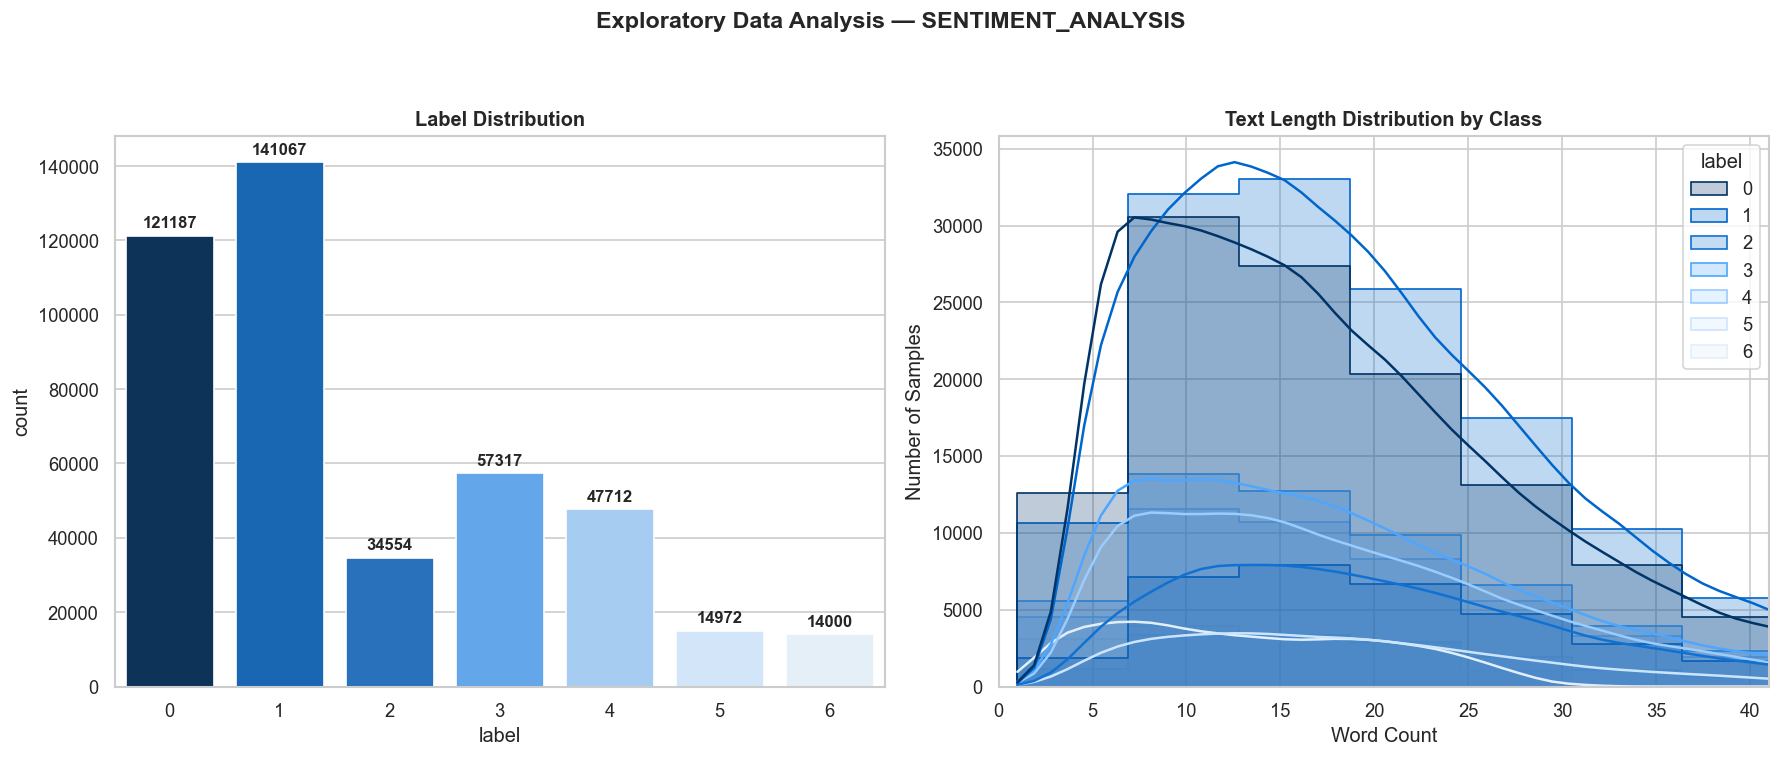

In [81]:
# -- 2.4 EDA Overview ---------------------------------------------------------
df_raw['text_len'] = df_raw['text'].fillna('').apply(lambda x: len(str(x).split()))

plot_path = CFG["output_paths"]["eda"] / "eda_overview.png"

if display_saved_plot(plot_path, title=f"EDA — {CFG['task']}"):
    print(f"Displayed existing plot: {plot_path}")
else:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    sns.countplot(
        data=df_raw,
        x=CFG["label_col"],
        order=CLASSES,  
        palette=COLORS, 
        ax=axes[0]
    )
    axes[0].set_title("Label Distribution", fontsize=12, fontweight="bold")
    
    for container in axes[0].containers:
        axes[0].bar_label(container, fontsize=10, fontweight="bold", padding=3)

    sns.histplot(
        data=df_raw,
        x="text_len",
        hue=CFG["label_col"],
        bins=30,               
        kde=True,
        palette=COLORS,
        element="step",        
        stat="count",          
        common_norm=False,    
        ax=axes[1]
    )
    
    max_len = df_raw['text_len'].quantile(0.95)
    axes[1].set_xlim(0, max_len if max_len > 0 else 100) 
    
    axes[1].set_title("Text Length Distribution by Class", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Word Count")
    axes[1].set_ylabel("Number of Samples")

    plt.suptitle(f"Exploratory Data Analysis — {CFG['task'].upper()}", 
                 fontsize=14, fontweight="bold", y=1.05)
    
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

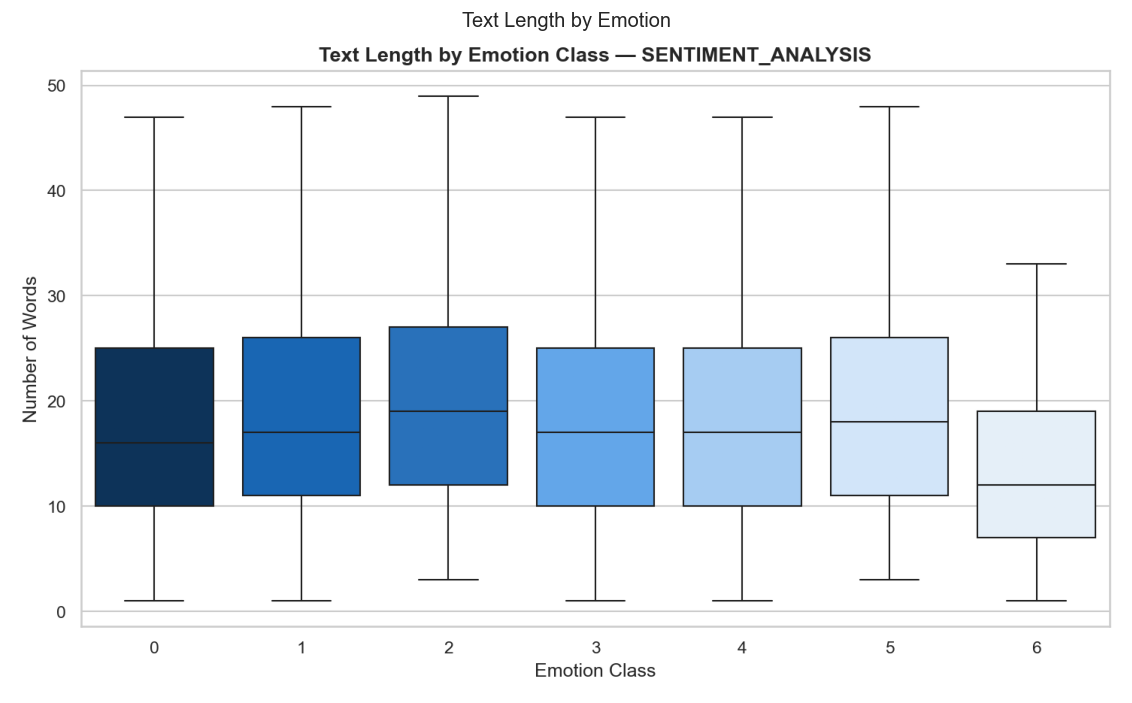

Displayed existing plot: outputs\eda\eda_text_length_by_class.png


In [90]:
# -- 2.5 Text Length by Class -------------------------------------------------
plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png"

if display_saved_plot(plot_path, title="Text Length by Emotion"):
    print(f"Displayed existing plot: {plot_path}")
else:
    # We create a single plot (1, 1) instead of (1, 2)
    fig, ax = plt.subplots(figsize=(10, 6))

    # Using df_raw and your label column
    sns.boxplot(
        data=df_raw, 
        x=CFG["label_col"], 
        y="text_len", 
        order=CLASSES,
        palette=COLORS, 
        ax=ax, 
        showfliers=False # Keeps the plot clean by hiding extreme outliers
    )

    ax.set_title(f"Text Length by Emotion Class — {CFG['task'].upper()}", 
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Emotion Class")
    ax.set_ylabel("Number of Words")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()


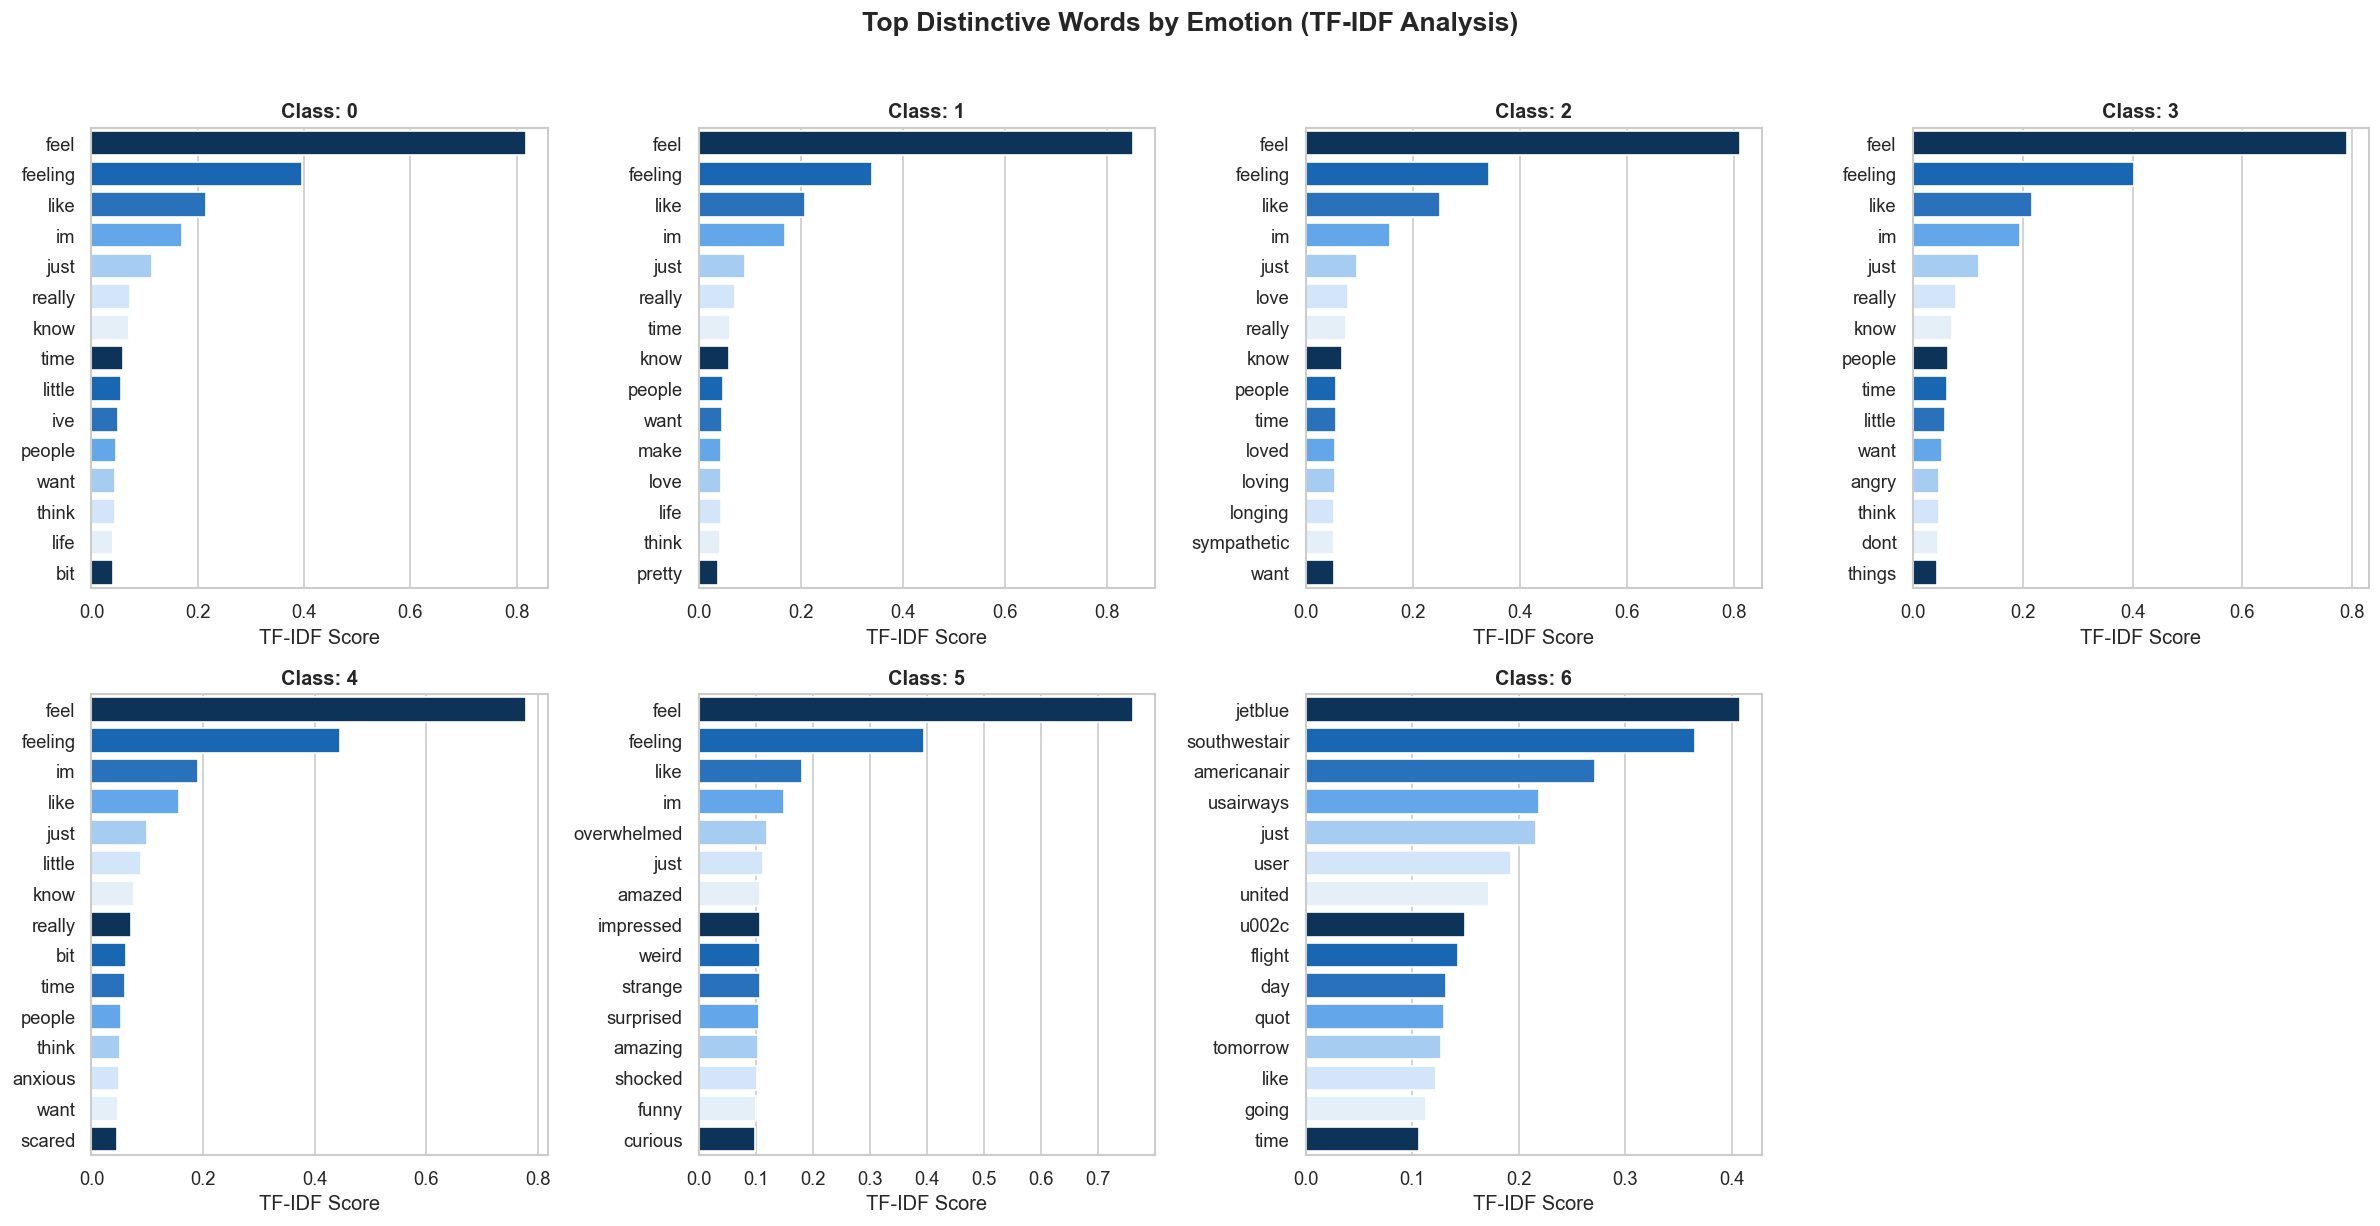

In [95]:
# -- 2.8 Top Words by Emotion (TF-IDF) ---------------------------------------
plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png"

if display_saved_plot(plot_path, title="Top Words by Emotion"):
    print(f"Displayed existing plot: {plot_path}")
else:
    # Set grid: 2 rows to fit all 7 classes comfortably
    n_classes = len(CLASSES)
    cols = 4
    rows = (n_classes + cols - 1) // cols  # Calculates needed rows
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 10))
    axes = axes.flatten() # Flatten to iterate easily

    for i, cls in enumerate(CLASSES):
        ax = axes[i]
        # Make sure get_top_words_tfidf handles your '6' or 'neutral' label
        top = get_top_words_tfidf(df_raw, cls)
        
        if top is not None and not top.empty:
            sns.barplot(data=top, y="word", x="score", ax=ax, palette=COLORS)
            ax.set_title(f"Class: {cls}", fontsize=12, fontweight="bold")
        else:
            ax.text(0.5, 0.5, 'No data', ha='center')
            
        ax.set_xlabel("TF-IDF Score")
        ax.set_ylabel("")

    # Remove empty subplots if any (e.g., if you have 7 classes in an 8-plot grid)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Top Distinctive Words by Emotion (TF-IDF Analysis)", 
                 fontsize=16, fontweight="bold", y=1.02)
    
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()


Generating Word Cloud... this may take a moment.


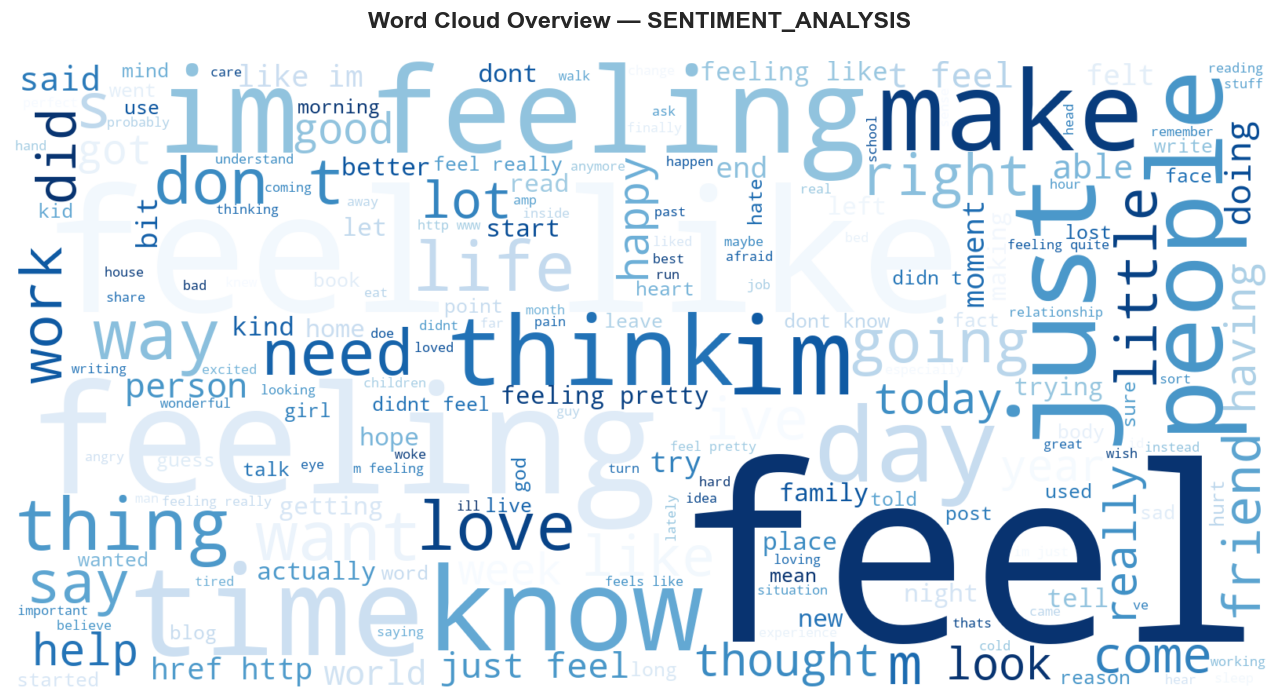

In [102]:
# -- 2.9 Word Cloud Overview --------------------------------------------------
from wordcloud import WordCloud

plot_path = CFG["output_paths"]["eda"] / "eda_wordcloud_overall.png"

if display_saved_plot(plot_path, title="Word Cloud of Dataset"):
    print(f"Displayed existing plot: {plot_path}")
else:
    print("Generating Word Cloud... this may take a moment.")
    
    
    text = " ".join(df_raw["text"].dropna().astype(str))

    wc = WordCloud(
        width=1600,       
        height=800,
        background_color="white",
        colormap="Blues", 
        max_words=200,
        stopwords=list(ENGLISH_STOP_WORDS.union(EXTRA_STOPWORDS)) 
    ).generate(text)

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    
    plt.title(f"Word Cloud Overview — {CFG['task'].upper()}", 
              fontsize=14, fontweight="bold", pad=20)
    
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

---
<a id="section-3-preprocessing"></a>
# SECTION 3 — Data preparation


## Preprocessing steps


In [96]:
# ── 3.1 datasets = [ ─────────────────────────────────────────
datasets = [
    ("raw_dataset", df_raw),
]


In [97]:
# ── 3.2 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    tqdm.pandas(desc="Preprocessing")

    for name, df in datasets:
        print(f"\nProcessing {name} ({len(df)} rows)")
        df["text_raw"] = df[CFG["text_col"]].progress_apply(normalize_text)
        df["text_clean"] = df["text_raw"].progress_apply(preprocess_from_normalized)
else:
    print("Skipping preprocessing (CFG['run_data_prep']=False)")



Processing raw_dataset (430809 rows)


Preprocessing:   0%|          | 0/430809 [00:00<?, ?it/s]

Preprocessing:   0%|          | 0/430809 [00:00<?, ?it/s]

In [98]:
# ── 3.3 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets:
        print(f"\nCleaning {name} (before: {len(df)})")
        
        df.dropna(subset=[CFG["text_col"], CFG["label_col"]], inplace=True)
        df.drop_duplicates(subset=[CFG["text_col"]], inplace=True)
        
        print(f"Final dataset size: {len(df)}")
else:
    print("Skipping dataset cleaning (CFG['run_data_prep']=False)")



Cleaning raw_dataset (before: 430809)
Final dataset size: 407767


In [99]:
# ── 3.4 class2id = {c: i for i, c in enumerate(CLASSES)} ─────────────────────────────────────────
class2id = {c: i for i, c in enumerate(CLASSES)}
id2class = {i: c for c, i in class2id.items()}


In [100]:
# ── 3.5 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets:
        df["age_enc"] = df[CFG["label_col"]].map(class2id)
else:
    print("Skipping label encoding for datasets (CFG['run_data_prep']=False)")


<a id="section-3-train-val-test-split"></a>
## Train/Val/Test split


In [103]:
print(df[CFG["label_col"]].value_counts())

label
1    135104
0    118505
3     54704
4     43656
2     29394
6     13945
5     12459
Name: count, dtype: int64


In [104]:
n_samples = 12400 

df_balanced = (
    df_raw.groupby(CFG["label_col"], group_keys=False)
          .sample(n=n_samples, replace=False, random_state=CFG["seed"])
).reset_index(drop=True)

df_balanced['text_raw'] = df_balanced['text']
df_balanced['label_enc'] = df_balanced[CFG["label_col"]].astype('category').cat.codes

print("Balanced Dataset Labels:")
print(df_balanced[CFG["label_col"]].value_counts())

Balanced Dataset Labels:
label
0    12400
1    12400
2    12400
3    12400
4    12400
5    12400
6    12400
Name: count, dtype: int64


In [105]:
# -- 3.6 Train/Val/Test Splits ------------------------------------------------
if CFG["run_data_prep"]:
    # Definimos las columnas que TU dataset sí tiene
    required_cols = ["text_raw", "text_clean", "label_enc"]
    
    missing = [c for c in required_cols if c not in df_balanced.columns]
    if missing:
        # Si falta 'text_clean', asegúrate de haber corrido la limpieza antes
        raise ValueError(f"Dataset: missing columns {missing}")

    # Creamos los splits directamente para tu dataset balanceado
    # Cambiamos la clave 'name' por algo descriptivo como 'sentiment_tweets'
    dataset_name = "sentiment_combined"
    splits = {
        dataset_name: make_splits_and_arrays(df_balanced, CFG)
    }

    s = splits[dataset_name]
    print(f"\n{dataset_name.upper()} Splits Ready:")
    print(f"  - Train: {len(s['df_train'])} samples")
    print(f"  - Val:   {len(s['df_val'])} samples")
    print(f"  - Test:  {len(s['df_test'])} samples")

    # Validación cruzada estratificada
    cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])
else:
    print("Skipping split creation (CFG['run_data_prep']=False)")

ValueError: Input y contains NaN.

In [101]:
# ── 3.6 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    splits = {}

    for name, df in datasets:
        required_cols = ["text_raw", "text_clean", "age_enc"]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"{name}: missing columns {missing}")

        splits[name] = make_splits_and_arrays(df, CFG)

        s = splits[name]
        print(f"{name} -> Train: {len(s['df_train'])} | Val: {len(s['df_val'])} | Test: {len(s['df_test'])}")

    cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])
else:
    print("Skipping split creation (CFG['run_data_prep']=False)")


ValueError: Input y contains NaN.

In [33]:
# ── 3.7 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    with open(CFG["data_dir"] / "abcde" / "reddit" / "splits.pkl", "wb") as f:
        pickle.dump(splits, f)
else:
    print("Skipping split serialization (CFG['run_data_prep']=False)")


Skipping split serialization (CFG['run_data_prep']=False)


In [34]:
# ── 3.8 splits = locals().get("splits") or {} ─────────────────────────────────────────
splits = locals().get("splits") or {}

if not splits:
    splits = load_pickle_with_fallback(
        CFG["data_dir"] / "abcde" / "reddit" / "splits.pkl",
    )


Loaded pickle: data/abcde/reddit/splits.pkl


---
<a id="section-5-baseline-models"></a>
# SECTION 5 — Baseline Models

Pipeline: **Majority Class → TF-IDF + LogReg → TF-IDF + SVC → TF-IDF + XGBoost**  


## 5.1 Preparation & Architecture

- Prepares baseline experiment artefacts and cache paths before model selection/training.
Constructs classical pipeline candidates (Majority Class, TF-IDF + LogReg/SVC/XGBoost).

In [35]:
# ── 5.1 baseline_models = build_baseline_pipeline_models(CFG) ─────────────────────────────────────────
baseline_models = build_baseline_pipeline_models(CFG)

best_models_cache = CFG["output_paths"]["metrics"] / "best_baseline_models.pkl"
tuning_cache = CFG["output_paths"]["metrics"] / "baseline_tuning_df.pkl"
legacy_baseline_dir = CFG["model_dir"] / "baselines"
canonical_baseline_exists = any(CFG["model_dir"].glob("tf_idf_*_reddit_*_*/best_model/model.pkl"))
legacy_baseline_exists = legacy_baseline_dir.exists() and any(legacy_baseline_dir.glob("*.pkl"))

if best_models_cache.exists() and tuning_cache.exists():
    best_baseline_models = joblib.load(best_models_cache)
    baseline_tuning_df = joblib.load(tuning_cache)
    print("Loaded cached baseline tuning artefacts -> skipping retuning.")
elif canonical_baseline_exists or legacy_baseline_exists:
    best_baseline_models = baseline_models
    baseline_tuning_df = pd.DataFrame([
        {
            "model": name,
            "params": "reuse_existing_models",
            "val_f1_macro": np.nan,
            "selected": True,
            "note": "tuning skipped because trained baseline artefacts already exist",
        }
        for name in baseline_models.keys()
    ])
    print("Detected existing baseline artefacts -> skipping retuning.")
else:
    best_baseline_models, baseline_tuning_df = tune_baselines_on_100k(
        models=baseline_models,
        split_100k=splits["reddit_100k"],
        seed=CFG["seed"],
        n_iter=4,
    )
    joblib.dump(best_baseline_models, best_models_cache)
    joblib.dump(baseline_tuning_df, tuning_cache)
    print("Best baseline selection completed on reddit_100k (val split).")

display(baseline_tuning_df)


Detected existing baseline artefacts -> skipping retuning.


,model,params,val_f1_macro,selected,note
0,Majority Class,reuse_existing_models,NaN,True,tuning skipped because trained baseline artefa...
1,TF-IDF + LogReg,reuse_existing_models,NaN,True,tuning skipped because trained baseline artefa...
2,TF-IDF + SVC,reuse_existing_models,NaN,True,tuning skipped because trained baseline artefa...
3,TF-IDF + XGBoost,reuse_existing_models,NaN,True,tuning skipped because trained baseline artefa...


In [36]:
# ── 5.2 le = DictLabelEncoder(class2id) ─────────────────────────────────────────
le = DictLabelEncoder(class2id)

## 5.3 Training


In [37]:
# ── 5.3 reddit_split_keys = [ ─────────────────────────────────────────
reddit_split_keys = [
    "reddit_1k", "reddit_5k", "reddit_10k",
    "reddit_50k", "reddit_100k", "reddit_500k",
]

baseline_curve_df, baseline_eval_df, BASELINE_MODEL_REGISTRY = train_baselines_across_splits(
    models=best_baseline_models,
    splits=splits,
    split_keys=reddit_split_keys,
    label_encoder=le,
    model_root=CFG["model_dir"],
    primary_curve_split="val",
    single_point_models=("Majority Class",),
    single_point_key="reddit_500k",
)


Baseline train/eval:   0%|          | 0/19 [00:00<?, ?it/s]


  TF-IDF + LogReg [reddit_1k] | VAL
  Accuracy      : 0.3067
  F1 (macro)    : 0.3069
  F1 (weighted) : 0.3069

              precision    recall  f1-score   support

       13-17       0.39      0.37      0.38        30
       18-29       0.19      0.23      0.21        30
       30-49       0.37      0.23      0.29        30
       50-64       0.27      0.27      0.27        30
         65+       0.36      0.43      0.39        30

    accuracy                           0.31       150
   macro avg       0.32      0.31      0.31       150
weighted avg       0.32      0.31      0.31       150


  TF-IDF + LogReg [reddit_1k] | TEST
  Accuracy      : 0.2933
  F1 (macro)    : 0.2893
  F1 (weighted) : 0.2893

              precision    recall  f1-score   support

       13-17       0.38      0.40      0.39        30
       18-29       0.30      0.40      0.34        30
       30-49       0.27      0.20      0.23        30
       50-64       0.20      0.20      0.20        30
         65+ 

## 5.4 Results


In [38]:
# ── 5.4 Show full evaluation table before learning-curve plot. ─────────────────────────────────────────
# Show full evaluation table before learning-curve plot.
display(
    baseline_eval_df
    .sort_values(["model", "train_size"])
    .reset_index(drop=True)
)


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,model_tag,model_path,status
0,Majority Class,reddit_500k,349111,test,0.200334,0.066759,0.066871,NaN,Majority Class [reddit_500k],models/majority_class_reddit_500k_20260304_150...,loaded
1,Majority Class,reddit_500k,349111,val,0.200334,0.066759,0.066871,NaN,Majority Class [reddit_500k],models/majority_class_reddit_500k_20260304_150...,loaded
2,TF-IDF + LogReg,reddit_1k,700,test,0.293333,0.289287,0.289287,NaN,TF-IDF + LogReg [reddit_1k],models/tf_idf_logreg_reddit_1k_20260302_144254...,loaded
3,TF-IDF + LogReg,reddit_1k,700,val,0.306667,0.306917,0.306917,NaN,TF-IDF + LogReg [reddit_1k],models/tf_idf_logreg_reddit_1k_20260302_144254...,loaded
4,TF-IDF + LogReg,reddit_5k,3499,test,0.326667,0.328023,0.328023,NaN,TF-IDF + LogReg [reddit_5k],models/tf_idf_logreg_reddit_5k_20260302_144256...,loaded
5,TF-IDF + LogReg,reddit_5k,3499,val,0.356000,0.358290,0.358290,NaN,TF-IDF + LogReg [reddit_5k],models/tf_idf_logreg_reddit_5k_20260302_144256...,loaded
6,TF-IDF + LogReg,reddit_10k,7000,test,0.375333,0.376052,0.376052,NaN,TF-IDF + LogReg [reddit_10k],models/tf_idf_logreg_reddit_10k_20260302_14430...,loaded
7,TF-IDF + LogReg,reddit_10k,7000,val,0.380000,0.378553,0.378553,NaN,TF-IDF + LogReg [reddit_10k],models/tf_idf_logreg_reddit_10k_20260302_14430...,loaded
8,TF-IDF + LogReg,reddit_50k,34976,test,0.403602,0.402885,0.402885,NaN,TF-IDF + LogReg [reddit_50k],models/tf_idf_logreg_reddit_50k_20260302_14350...,loaded
9,TF-IDF + LogReg,reddit_50k,34976,val,0.409873,0.408984,0.408969,NaN,TF-IDF + LogReg [reddit_50k],models/tf_idf_logreg_reddit_50k_20260302_14350...,loaded


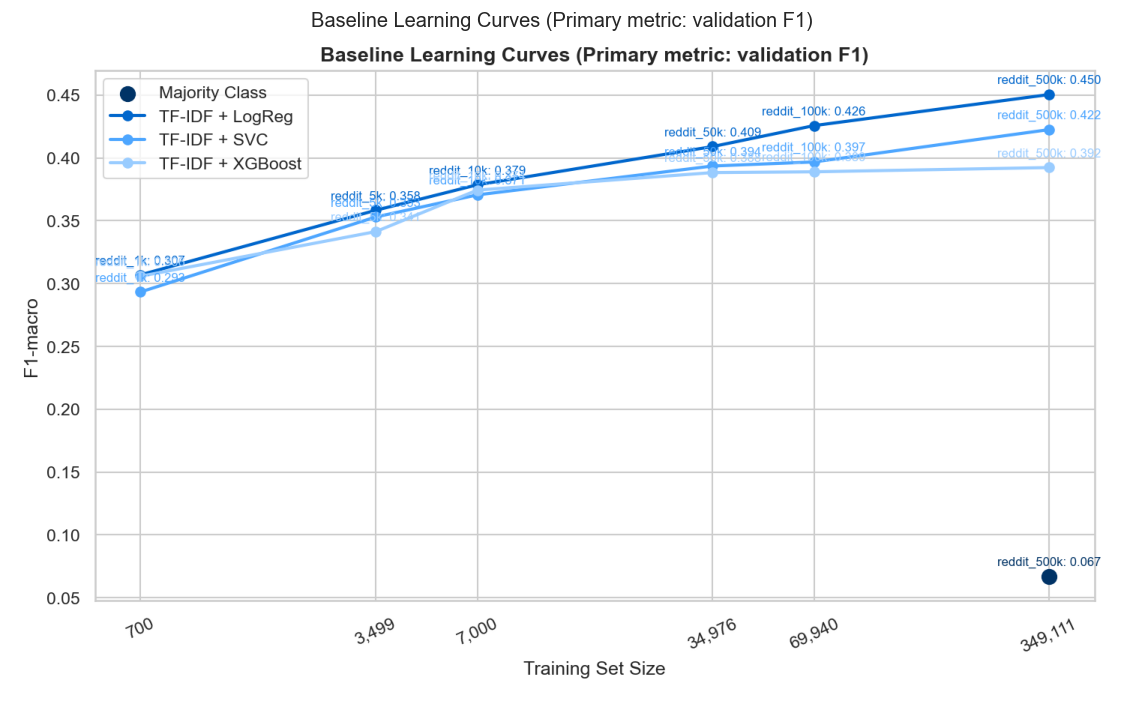

Displayed existing learning curve: outputs/plots/learning_curves/baseline_learning_curves.png


,model,split_key,train_size,f1_macro
0,Majority Class,reddit_500k,349111,0.066759
1,TF-IDF + LogReg,reddit_1k,700,0.306917
2,TF-IDF + LogReg,reddit_5k,3499,0.358290
3,TF-IDF + LogReg,reddit_10k,7000,0.378553
4,TF-IDF + LogReg,reddit_50k,34976,0.408984
5,TF-IDF + LogReg,reddit_100k,69940,0.425649
6,TF-IDF + LogReg,reddit_500k,349111,0.450380
7,TF-IDF + SVC,reddit_1k,700,0.293268
8,TF-IDF + SVC,reddit_5k,3499,0.352973
9,TF-IDF + SVC,reddit_10k,7000,0.370524


In [39]:
# ── 5.5 plot_learning_curve_from_metrics( ─────────────────────────────────────────
plot_learning_curve_from_metrics(
    baseline_curve_df,
    title="Baseline Learning Curves (Primary metric: validation F1)",
    save_path=CFG["output_paths"]["plots_learning"] / "baseline_learning_curves.png",
)


In [40]:
# ── 5.6 Persist baseline metrics and model registry ─────────────────────────────────────────
# Persist baseline metrics and model registry
metrics_dir = CFG["output_paths"]["metrics"]
metrics_dir.mkdir(parents=True, exist_ok=True)

baseline_curve_df.to_csv(metrics_dir / "baseline_curve_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "baseline_curve_metrics.pkl")

baseline_eval_df.to_csv(metrics_dir / "baseline_eval_metrics.csv", index=False)
joblib.dump(baseline_eval_df, metrics_dir / "baseline_eval_metrics.pkl")

# unified classical curve file (used later by section 9.5)
baseline_curve_df.to_csv(metrics_dir / "classical_lc_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "classical_lc_metrics.pkl")

with open(metrics_dir / "baseline_model_registry.json", "w", encoding="utf-8") as f:
    json.dump(BASELINE_MODEL_REGISTRY, f, indent=2)

# Store compact LC entries in RESULTS for unified reporting
for row in baseline_curve_df.itertuples(index=False):
    RESULTS[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}


---
<a id="section-6-static-embeddings-fasttext"></a>
# SECTION 6 — Static Embeddings + Models (FastText, MLP + CNN)

## 6.1 Preparation & Architecture

Builds a vocabulary from the training set and creates a fixed embedding matrix  
shared by all deep learning models (MLP, CNN, BiLSTM).

In [41]:
# ── 6.1 Prepare split keys for deep learning experiments ─────────────────────────────────────────
# Prepare split keys for deep learning experiments
reddit_split_keys_dl = ["reddit_10k", "reddit_100k", "reddit_500k"]
base_split_key_dl = "reddit_500k"

# Keep base variables for downstream cells that expect X_train / y_train, etc.
base_split = splits[base_split_key_dl]
X_train, X_val, X_test = base_split["X_train"], base_split["X_val"], base_split["X_test"]
X_train_raw, X_val_raw, X_test_raw = base_split["X_train_raw"], base_split["X_val_raw"], base_split["X_test_raw"]
y_train, y_val, y_test = base_split["y_train"], base_split["y_val"], base_split["y_test"]
df_train, df_val, df_test = base_split["df_train"], base_split["df_val"], base_split["df_test"]

for name in reddit_split_keys_dl:
    s = splits[name]
    print(
        f"{name}: train={len(s['X_train']):,} | "
        f"val={len(s['X_val']):,} | test={len(s['X_test']):,}"
    )
print(f"Base split for shared vocabulary/embeddings: {base_split_key_dl}")


reddit_10k: train=7,000 | val=1,500 | test=1,500
reddit_100k: train=69,940 | val=14,988 | test=14,988
reddit_500k: train=349,111 | val=74,810 | test=74,810
Base split for shared vocabulary/embeddings: reddit_500k


In [42]:
# ── 6.2 vocab = build_vocab( ─────────────────────────────────────────
vocab = build_vocab(
    X_train,
    max_vocab=50_000,
    min_freq=1,
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"],
)

print(f"Vocabulary size: {len(vocab):,}")


Vocabulary size: 50,000


In [43]:
# ── 6.3 vocab_words = set(vocab.keys()) ─────────────────────────────────────────
vocab_words = set(vocab.keys())
total = 0
oov = 0

for text in X_val:   # or X_test
    toks = str(text).split()
    total += len(toks)
    oov += sum(tok not in vocab_words for tok in toks)

print(f"OOV rate: {oov/total:.2%}  ({oov}/{total})")


OOV rate: 12.46%  (669451/5373815)


In [44]:
# ── 6.4 embedding_matrix = load_embedding_matrix( ─────────────────────────────────────────
embedding_matrix = load_embedding_matrix(
    vocab, CFG["embedding_model"], CFG["embedding_dim"]
)
print(f"Embedding matrix shape: {embedding_matrix.shape}")


INFO:gensim.models.keyedvectors:loading projection weights from /Users/georgijkutivadze/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz


Loading fasttext-wiki-news-subwords-300 ...


INFO:gensim.utils:KeyedVectors lifecycle event {'msg': 'loaded (999999, 300) matrix of type float32 from /Users/georgijkutivadze/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-03-05T09:08:54.597962', 'gensim': '4.4.0', 'python': '3.11.11 | packaged by conda-forge | (main, Dec  5 2024, 08:47:03) [Clang 18.1.8 ]', 'platform': 'macOS-26.3-arm64-arm-64bit', 'event': 'load_word2vec_format'}


Coverage: 56.3%  (hits=28134, misses=21866)
Embedding matrix shape: (50000, 300)


In [45]:
# ── 6.5 seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"]) ─────────────────────────────────────────
seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val   = texts_to_sequences(X_val,   vocab, CFG["max_seq_len"])
seq_test  = texts_to_sequences(X_test,  vocab, CFG["max_seq_len"])

print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")


seq_train: (349111, 128) | seq_val: (74810, 128) | seq_test: (74810, 128)


In [46]:
# ── 6.6 Base split loaders (kept for compatibility with downstream code) ─────────────────────────────────────────
# Base split loaders (kept for compatibility with downstream code)
loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"]
)
print("Base split DataLoaders ready.")


# Prepare sequence tensors + loaders for each target reddit split
# Reuses the same vocab/embedding_matrix for fair cross-split comparison.
dl_split_data = {}
for split_key in reddit_split_keys_dl:
    s = splits[split_key]

    seq_tr = texts_to_sequences(s["X_train"], vocab, CFG["max_seq_len"])
    seq_va = texts_to_sequences(s["X_val"],   vocab, CFG["max_seq_len"])
    seq_te = texts_to_sequences(s["X_test"],  vocab, CFG["max_seq_len"])

    l_tr, l_va, l_te = make_loaders(
        seq_tr, s["y_train"],
        seq_va, s["y_val"],
        seq_te, s["y_test"],
        batch_size=CFG["dl_batch_size"]
    )

    dl_split_data[split_key] = {
        "loader_train": l_tr,
        "loader_val": l_va,
        "loader_test": l_te,
        "y_val": s["y_val"],
        "y_test": s["y_test"],
        "df_test": s["df_test"],
        "train_size": len(s["X_train"]),
    }

    print(
        f"{split_key}: seq_train={seq_tr.shape}, seq_val={seq_va.shape}, "
        f"seq_test={seq_te.shape}"
    )

print("All deep-learning split DataLoaders ready.")


Base split DataLoaders ready.
reddit_10k: seq_train=(7000, 128), seq_val=(1500, 128), seq_test=(1500, 128)
reddit_100k: seq_train=(69940, 128), seq_val=(14988, 128), seq_test=(14988, 128)
reddit_500k: seq_train=(349111, 128), seq_val=(74810, 128), seq_test=(74810, 128)
All deep-learning split DataLoaders ready.


**Architecture:**
- *EmbeddingMLP* — mean-pool embeddings → FC head (document-level baseline).  
- *TextCNN* (Kim 2014) — parallel Conv1d filters [2, 3, 4] → global max-pool → concat → FC.

In [47]:
# ── 6.7 class EmbeddingMLP(nn.Module): ─────────────────────────────────────────
class EmbeddingMLP(nn.Module):
    """
    Mean-pools pre-trained token embeddings, then applies a two-layer MLP.
    Serves as the lightweight "GloVe + MLP" step in the pipeline.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    hidden_dim       : hidden layer width
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are not updated during training
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 hidden_dim: int = 256, dropout: float = 0.3,
                 freeze_emb: bool = False):
        super().__init__()
        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)       # (B, L, 1) — zero out PAD
        emb  = self.embedding(x) * mask             # (B, L, D)
        doc  = emb.sum(1) / mask.sum(1).clamp(min=1)  # masked mean → (B, D)
        return self.fc(doc)


# ── 8.2 TextCNN ───────────────────────────────────────────────────────────────
class TextCNN(nn.Module):
    """
    Parallel Conv1d filters over token embeddings with global max-pooling.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    num_filters      : number of filters per kernel size
    kernel_sizes     : list of filter heights (e.g. [2, 3, 4])
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are frozen
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 num_filters: int = 128, kernel_sizes: list = None,
                 dropout: float = 0.3, freeze_emb: bool = False):
        super().__init__()
        if kernel_sizes is None:
            kernel_sizes = [2, 3, 4]

        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)    # (B, D, L)
        pooled = [
            F.relu(conv(emb)).max(dim=2).values      # (B, F)
            for conv in self.convs
        ]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


print("EmbeddingMLP and TextCNN architectures defined.")


EmbeddingMLP and TextCNN architectures defined.


## 6.3 Training

Runs deep-model training/evaluation and produces deep/unified learning-curve artefacts.


In [48]:
# ── 6.8 CMAP = sns.light_palette(COLORS[0], as_cmap=True) ─────────────────────────────────────────
CMAP = sns.light_palette(COLORS[0], as_cmap=True)



===== GloVe MLP | reddit_10k =====
GloVe MLP [reddit_10k]: best checkpoint found -> skip retraining (models/glove_mlp_reddit_10k_20260302_161016/best_model/best.pt)


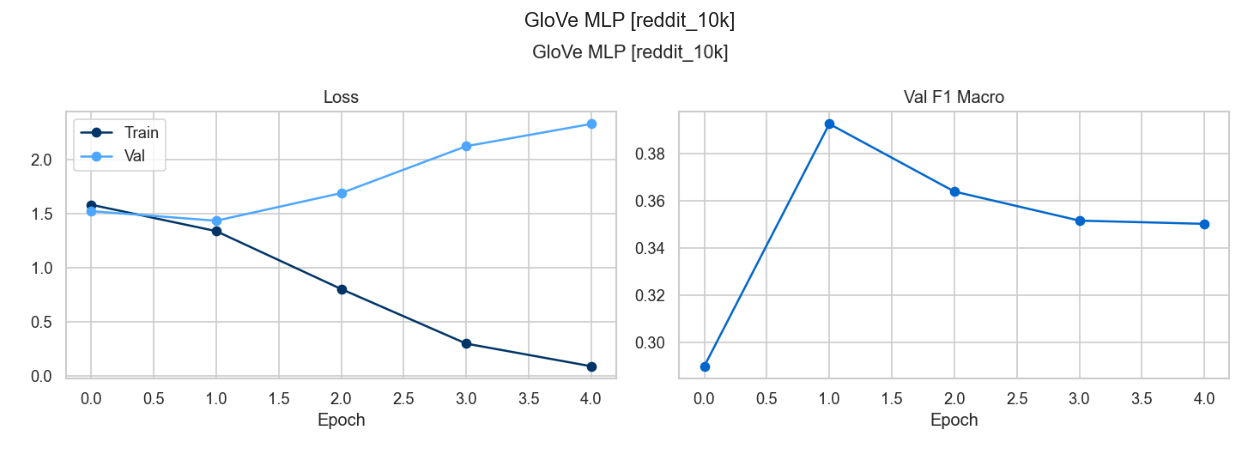

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_reddit_10k.png

  GloVe MLP [reddit_10k] | VAL
  Accuracy      : 0.3953
  F1 (macro)    : 0.3927
  F1 (weighted) : 0.3927

              precision    recall  f1-score   support

       13-17       0.43      0.53      0.48       300
       18-29       0.34      0.38      0.36       300
       30-49       0.38      0.27      0.32       300
       50-64       0.35      0.39      0.37       300
         65+       0.49      0.41      0.44       300

    accuracy                           0.40      1500
   macro avg       0.40      0.40      0.39      1500
weighted avg       0.40      0.40      0.39      1500

Final validation F1 (macro) [GloVe MLP [reddit_10k]]: 0.3927

  GloVe MLP [reddit_10k] | TEST
  Accuracy      : 0.3573
  F1 (macro)    : 0.3532
  F1 (weighted) : 0.3532

              precision    recall  f1-score   support

       13-17       0.41      0.55      0.47       300
       18-29       0.31   

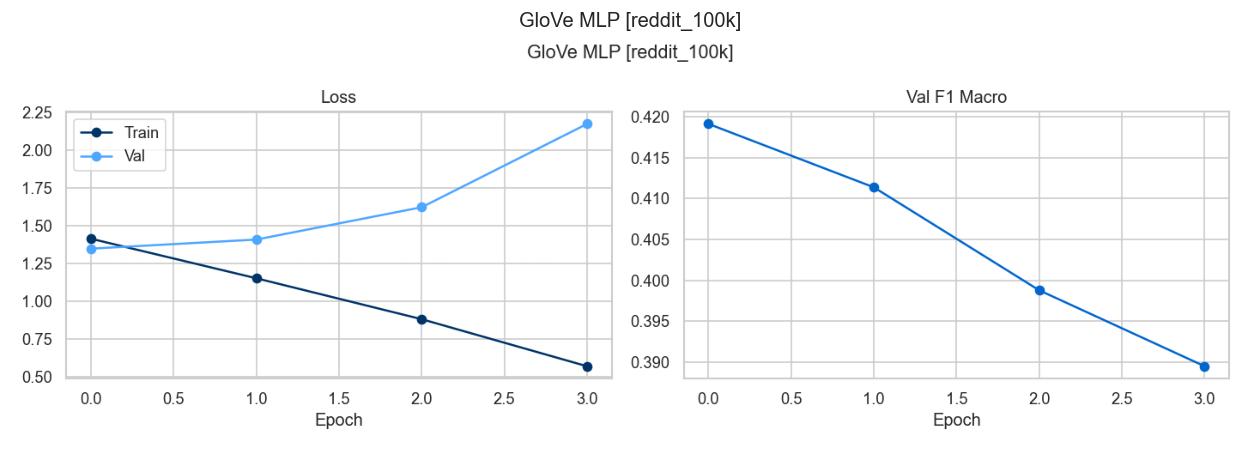

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_reddit_100k.png

  GloVe MLP [reddit_100k] | VAL
  Accuracy      : 0.4189
  F1 (macro)    : 0.4192
  F1 (weighted) : 0.4191

              precision    recall  f1-score   support

       13-17       0.51      0.53      0.52      2997
       18-29       0.33      0.35      0.34      2999
       30-49       0.39      0.35      0.37      2998
       50-64       0.37      0.50      0.42      2998
         65+       0.55      0.37      0.44      2996

    accuracy                           0.42     14988
   macro avg       0.43      0.42      0.42     14988
weighted avg       0.43      0.42      0.42     14988

Final validation F1 (macro) [GloVe MLP [reddit_100k]]: 0.4192

  GloVe MLP [reddit_100k] | TEST
  Accuracy      : 0.4145
  F1 (macro)    : 0.4146
  F1 (weighted) : 0.4146

              precision    recall  f1-score   support

       13-17       0.51      0.52      0.51      2997
       18-29       0.3

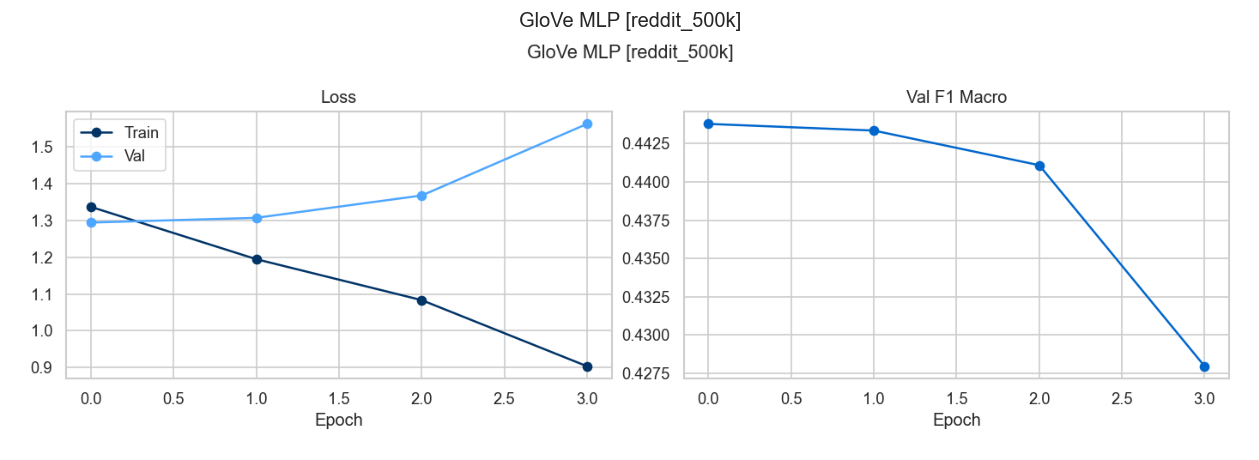

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_reddit_500k.png

  GloVe MLP [reddit_500k] | VAL
  Accuracy      : 0.4457
  F1 (macro)    : 0.4438
  F1 (weighted) : 0.4438

              precision    recall  f1-score   support

       13-17       0.49      0.61      0.54     14966
       18-29       0.36      0.35      0.35     14987
       30-49       0.40      0.40      0.40     14951
       50-64       0.43      0.47      0.45     14956
         65+       0.57      0.40      0.47     14950

    accuracy                           0.45     74810
   macro avg       0.45      0.45      0.44     74810
weighted avg       0.45      0.45      0.44     74810

Final validation F1 (macro) [GloVe MLP [reddit_500k]]: 0.4438

  GloVe MLP [reddit_500k] | TEST
  Accuracy      : 0.4452
  F1 (macro)    : 0.4433
  F1 (weighted) : 0.4432

              precision    recall  f1-score   support

       13-17       0.49      0.61      0.55     14966
       18-29       0.3

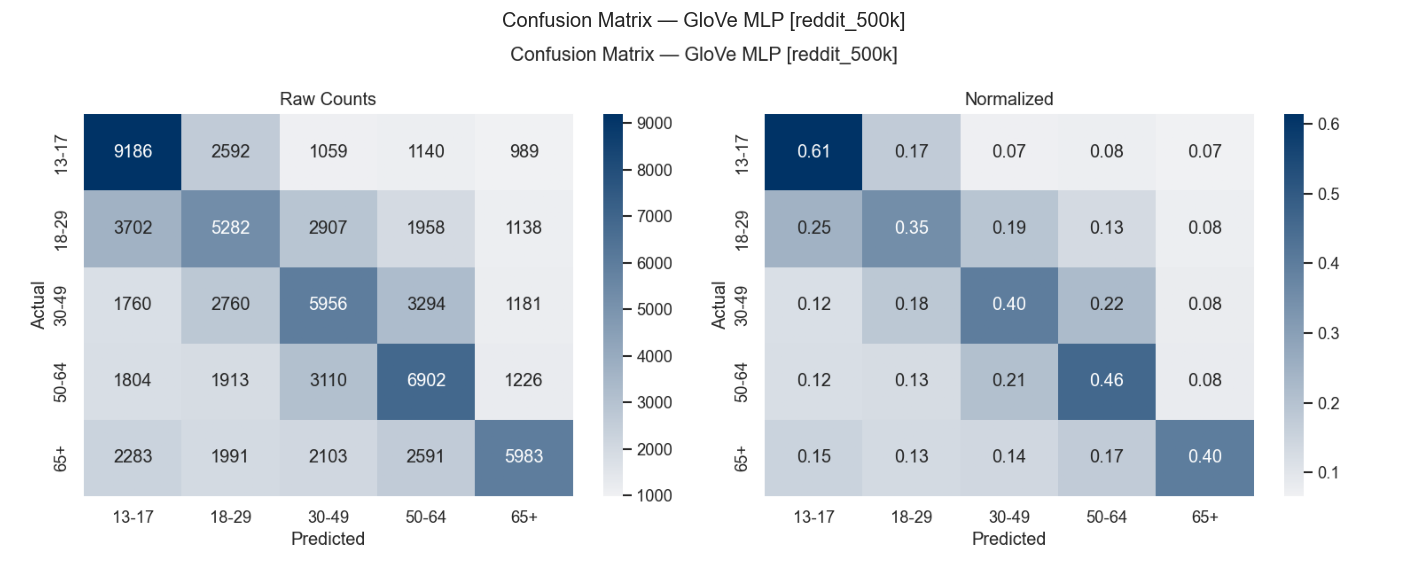

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_mlp_reddit_500k.png


In [49]:
# ── 6.9 deep_curve_rows = [] ─────────────────────────────────────────
deep_curve_rows = []
deep_eval_rows = []
deep_histories = {}
deep_test_preds = {}

for split_key in reddit_split_keys_dl:
    print()
    print(f"===== GloVe MLP | {split_key} =====")
    split_data = dl_split_data[split_key]

    mlp_model, mlp_history, val_metrics, test_metrics, mlp_preds = run_torch_experiment(
        model_label="GloVe MLP",
        family_slug="glove_mlp",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: EmbeddingMLP(
            embedding_matrix=embedding_matrix,
            num_classes=CFG["num_labels"],
            hidden_dim=256,
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe MLP [{split_key}]"
    deep_histories[run_name] = mlp_history
    deep_test_preds[run_name] = mlp_preds

    deep_curve_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "reddit_500k":
        plot_confusion_matrix_clf(split_data["y_test"], mlp_preds, run_name, le)



===== GloVe CNN | reddit_10k =====
GloVe CNN [reddit_10k]: best checkpoint found -> skip retraining (models/glove_cnn_reddit_10k_20260302_162054/best_model/best.pt)


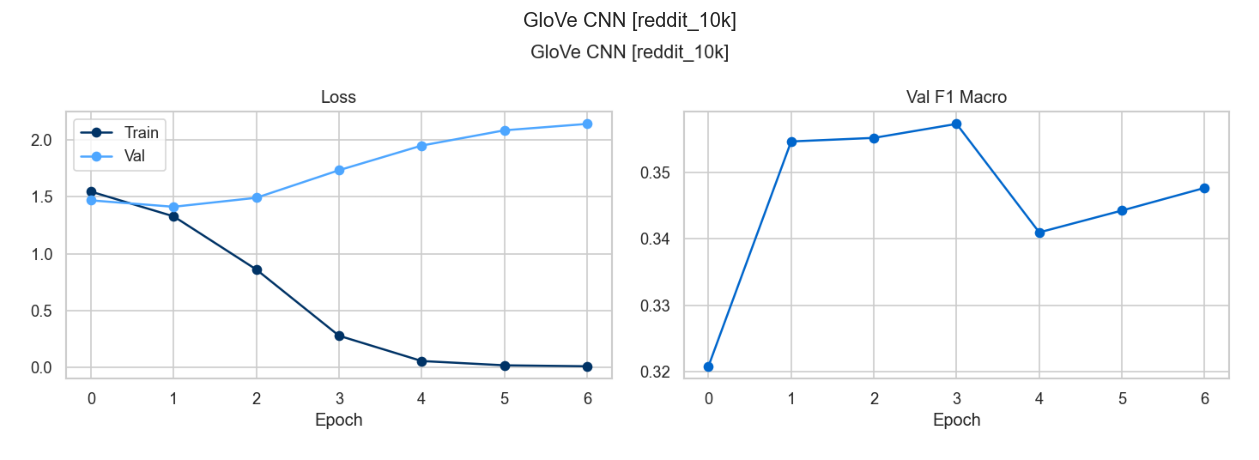

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_reddit_10k.png

  GloVe CNN [reddit_10k] | VAL
  Accuracy      : 0.3553
  F1 (macro)    : 0.3573
  F1 (weighted) : 0.3573

              precision    recall  f1-score   support

       13-17       0.42      0.40      0.41       300
       18-29       0.27      0.28      0.28       300
       30-49       0.35      0.37      0.36       300
       50-64       0.29      0.31      0.30       300
         65+       0.48      0.42      0.45       300

    accuracy                           0.36      1500
   macro avg       0.36      0.36      0.36      1500
weighted avg       0.36      0.36      0.36      1500

Final validation F1 (macro) [GloVe CNN [reddit_10k]]: 0.3573

  GloVe CNN [reddit_10k] | TEST
  Accuracy      : 0.3513
  F1 (macro)    : 0.3519
  F1 (weighted) : 0.3519

              precision    recall  f1-score   support

       13-17       0.44      0.46      0.45       300
       18-29       0.28   

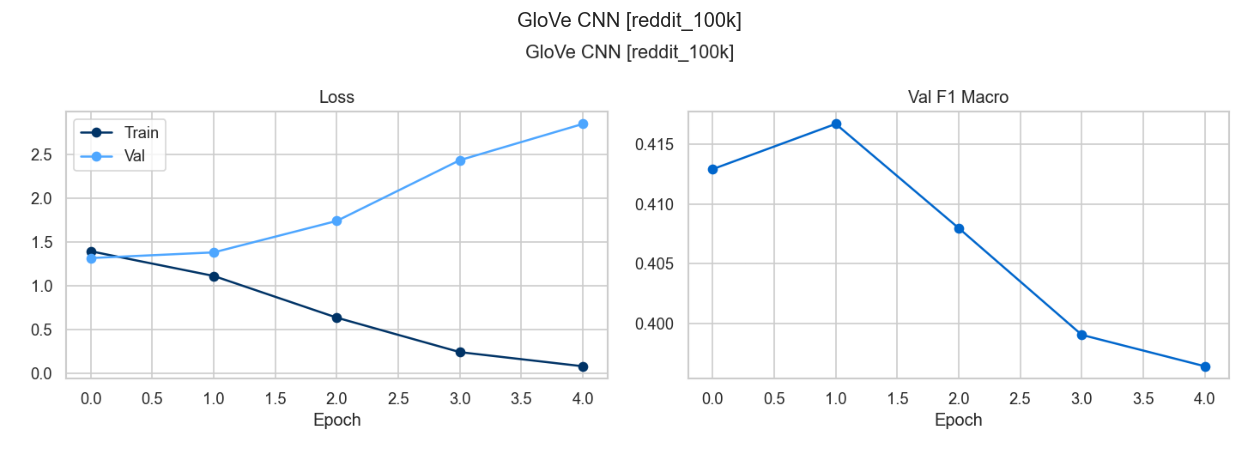

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_reddit_100k.png

  GloVe CNN [reddit_100k] | VAL
  Accuracy      : 0.4192
  F1 (macro)    : 0.4167
  F1 (weighted) : 0.4167

              precision    recall  f1-score   support

       13-17       0.51      0.50      0.51      2997
       18-29       0.34      0.42      0.37      2999
       30-49       0.46      0.26      0.33      2998
       50-64       0.36      0.53      0.43      2998
         65+       0.53      0.39      0.45      2996

    accuracy                           0.42     14988
   macro avg       0.44      0.42      0.42     14988
weighted avg       0.44      0.42      0.42     14988

Final validation F1 (macro) [GloVe CNN [reddit_100k]]: 0.4167

  GloVe CNN [reddit_100k] | TEST
  Accuracy      : 0.4175
  F1 (macro)    : 0.4146
  F1 (weighted) : 0.4146

              precision    recall  f1-score   support

       13-17       0.51      0.50      0.50      2997
       18-29       0.3

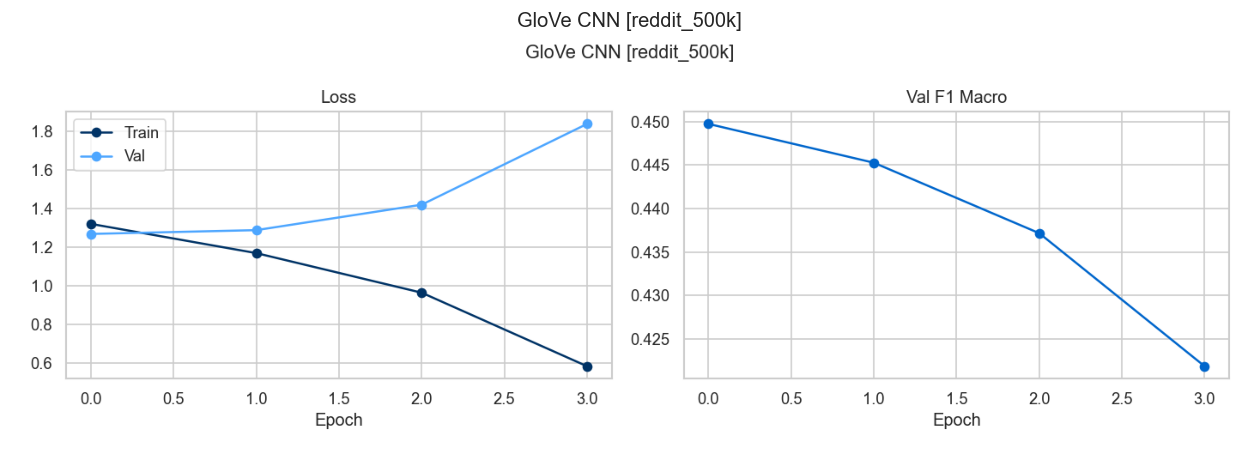

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_reddit_500k.png

  GloVe CNN [reddit_500k] | VAL
  Accuracy      : 0.4536
  F1 (macro)    : 0.4497
  F1 (weighted) : 0.4497

              precision    recall  f1-score   support

       13-17       0.50      0.61      0.55     14966
       18-29       0.39      0.37      0.38     14987
       30-49       0.45      0.33      0.38     14951
       50-64       0.38      0.58      0.46     14956
         65+       0.65      0.37      0.47     14950

    accuracy                           0.45     74810
   macro avg       0.47      0.45      0.45     74810
weighted avg       0.47      0.45      0.45     74810

Final validation F1 (macro) [GloVe CNN [reddit_500k]]: 0.4497

  GloVe CNN [reddit_500k] | TEST
  Accuracy      : 0.4511
  F1 (macro)    : 0.4470
  F1 (weighted) : 0.4470

              precision    recall  f1-score   support

       13-17       0.50      0.61      0.55     14966
       18-29       0.3

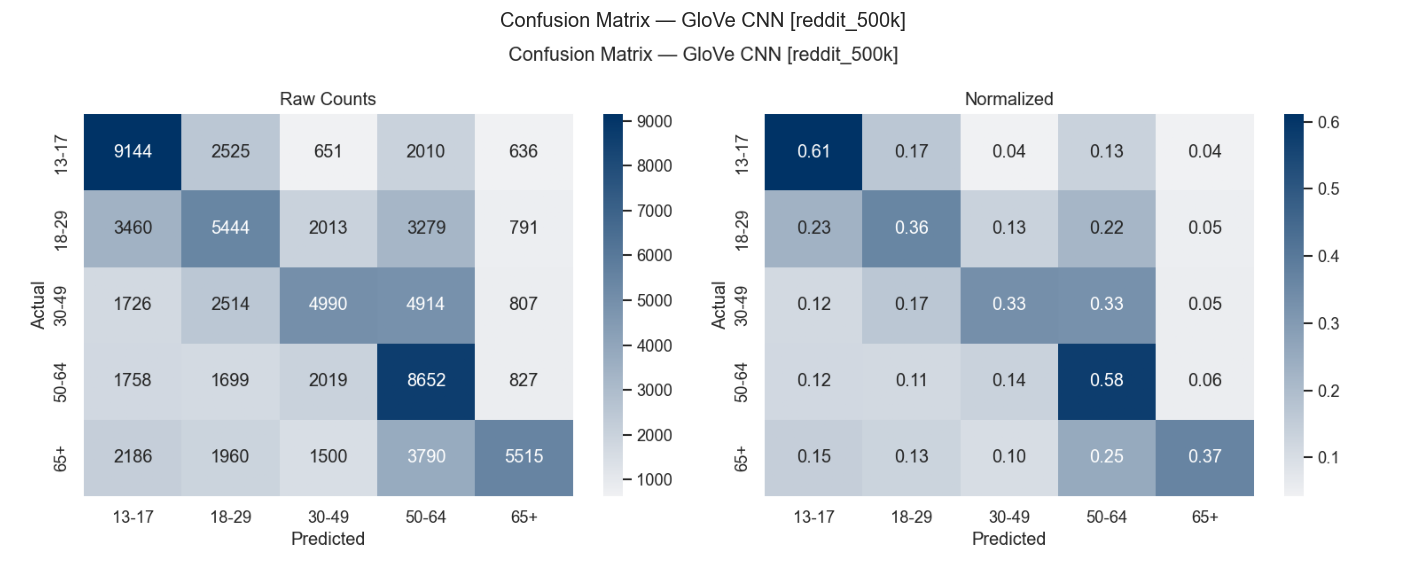

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_cnn_reddit_500k.png


In [50]:
# ── 6.10 for split_key in reddit_split_keys_dl: ─────────────────────────────────────────
for split_key in reddit_split_keys_dl:
    print()
    print(f"===== GloVe CNN | {split_key} =====")
    split_data = dl_split_data[split_key]

    cnn_model, cnn_history, val_metrics, test_metrics, cnn_preds = run_torch_experiment(
        model_label="GloVe CNN",
        family_slug="glove_cnn",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: TextCNN(
            embedding_matrix=embedding_matrix,
            num_classes=CFG["num_labels"],
            num_filters=CFG["cnn_num_filters"],
            kernel_sizes=CFG["cnn_kernel_sizes"],
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe CNN [{split_key}]"
    deep_histories[run_name] = cnn_history
    deep_test_preds[run_name] = cnn_preds

    deep_curve_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "reddit_500k":
        plot_confusion_matrix_clf(split_data["y_test"], cnn_preds, run_name, le)


## 6.4 Results

---
<a id="section-7-recurrent-models-bilstm-bigru"></a>
# SECTION 7 — Recurrent Models (BiLSTM / BiGRU)

## 7.1 Preparation & Architecture

**BiLSTM with additive attention** — captures long-range dependencies.  
Swap `nn.LSTM` → `nn.GRU` in the constructor for a lighter BiGRU.


In [51]:
# ── 7.1 class AdditiveAttention(nn.Module): ─────────────────────────────────────────
class AdditiveAttention(nn.Module):
    """
    Computes a weighted average over LSTM hidden states.
    Weights are learned via a single linear layer + softmax.
    Padding positions are masked out before softmax.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h, mask=None):
        scores = self.attn(h).squeeze(-1)                       # (B, L)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)                  # (B, L)
        context = (weights.unsqueeze(-1) * h).sum(dim=1)        # (B, H)
        return context, weights


# ── 9.2 BiLSTM + Attention ────────────────────────────────────────────────────
class BiLSTMAttention(nn.Module):
    """
    Bidirectional LSTM with additive attention for text classification.

    Parameters
    ----------
    embedding_matrix : np.ndarray, shape (vocab_size, embed_dim)
    num_classes      : number of output classes
    hidden_dim       : LSTM hidden state size per direction
    num_layers       : number of stacked LSTM layers
    dropout          : dropout probability
    freeze_emb       : freeze pre-trained embeddings during training
    """
    def __init__(self, embedding_matrix: np.ndarray, num_classes: int,
                 hidden_dim: int = 128, num_layers: int = 2,
                 dropout: float = 0.3, freeze_emb: bool = False):
        super().__init__()
        _, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = AdditiveAttention(hidden_dim * 2)   # *2 for bidirectional
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        mask = (x != 0)                              # (B, L) True = real token
        emb  = self.dropout(self.embedding(x))       # (B, L, D)
        h, _ = self.lstm(emb)                        # (B, L, 2*H)
        ctx, _ = self.attention(h, mask)             # (B, 2*H)
        return self.fc(self.dropout(ctx))


print("BiLSTMAttention architecture defined.")


BiLSTMAttention architecture defined.


## 7.3 Training



===== GloVe BiLSTM | reddit_10k =====
GloVe BiLSTM [reddit_10k]: best checkpoint found -> skip retraining (models/glove_bilstm_reddit_10k_20260302_163731/best_model/best.pt)


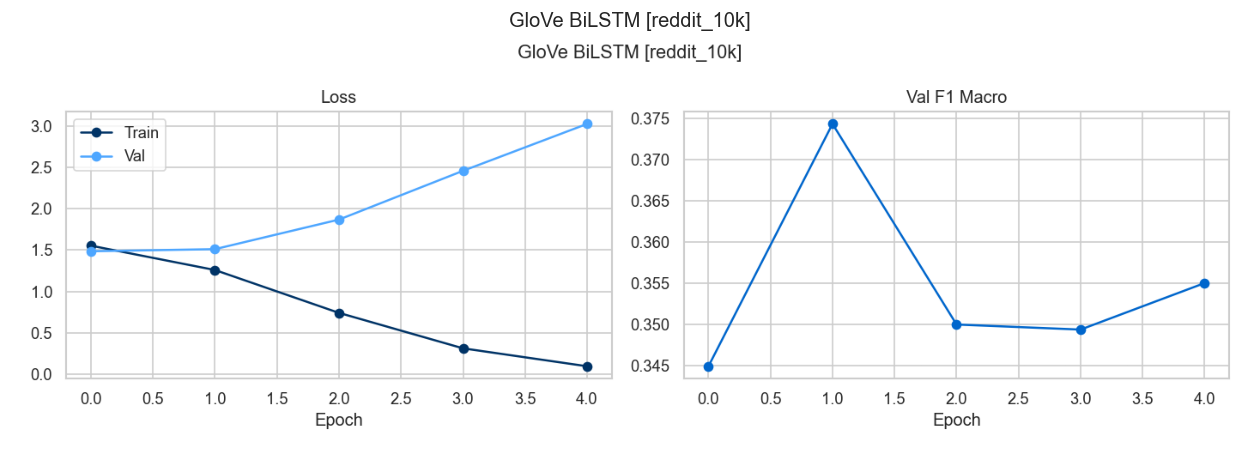

Displayed existing training curve: outputs/plots/training_curves/history_glove_bilstm_reddit_10k.png

  GloVe BiLSTM [reddit_10k] | VAL
  Accuracy      : 0.3647
  F1 (macro)    : 0.3602
  F1 (weighted) : 0.3602

              precision    recall  f1-score   support

       13-17       0.49      0.29      0.36       300
       18-29       0.30      0.40      0.34       300
       30-49       0.43      0.25      0.31       300
       50-64       0.29      0.65      0.40       300
         65+       0.88      0.25      0.39       300

    accuracy                           0.36      1500
   macro avg       0.48      0.36      0.36      1500
weighted avg       0.48      0.36      0.36      1500

Final validation F1 (macro) [GloVe BiLSTM [reddit_10k]]: 0.3602

  GloVe BiLSTM [reddit_10k] | TEST
  Accuracy      : 0.3513
  F1 (macro)    : 0.3446
  F1 (weighted) : 0.3446

              precision    recall  f1-score   support

       13-17       0.58      0.34      0.43       300
       18-29  

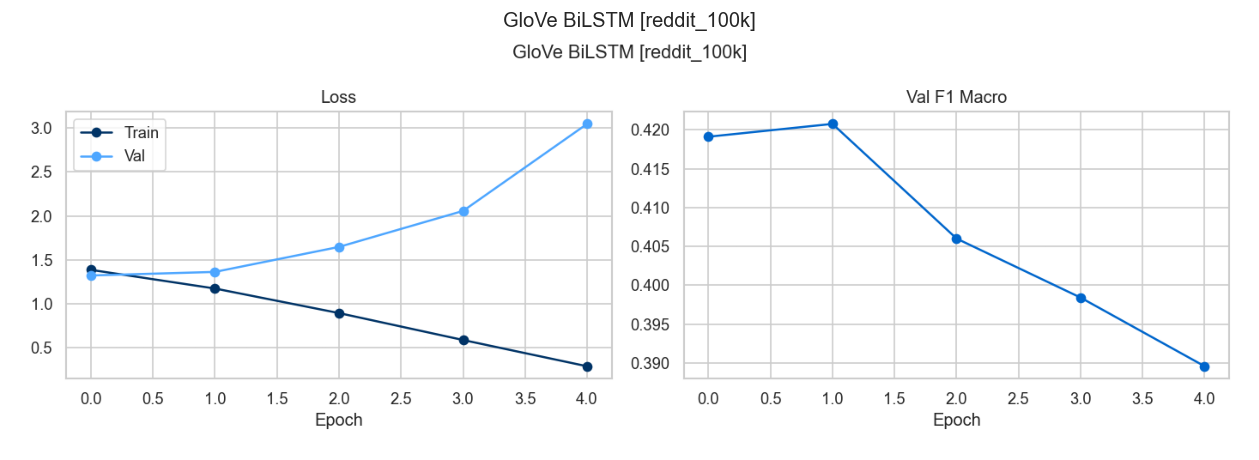

Displayed existing training curve: outputs/plots/training_curves/history_glove_bilstm_reddit_100k.png

  GloVe BiLSTM [reddit_100k] | VAL
  Accuracy      : 0.4203
  F1 (macro)    : 0.4223
  F1 (weighted) : 0.4223

              precision    recall  f1-score   support

       13-17       0.52      0.49      0.50      2997
       18-29       0.33      0.43      0.37      2999
       30-49       0.38      0.43      0.40      2998
       50-64       0.42      0.34      0.37      2998
         65+       0.51      0.41      0.46      2996

    accuracy                           0.42     14988
   macro avg       0.43      0.42      0.42     14988
weighted avg       0.43      0.42      0.42     14988

Final validation F1 (macro) [GloVe BiLSTM [reddit_100k]]: 0.4223

  GloVe BiLSTM [reddit_100k] | TEST
  Accuracy      : 0.4129
  F1 (macro)    : 0.4150
  F1 (weighted) : 0.4150

              precision    recall  f1-score   support

       13-17       0.51      0.47      0.49      2997
       18-

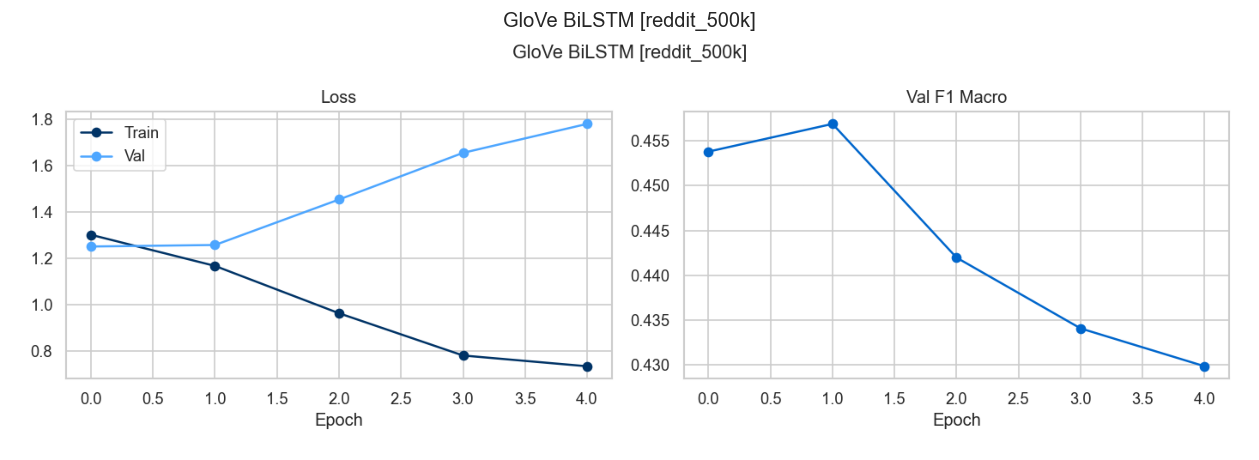

Displayed existing training curve: outputs/plots/training_curves/history_glove_bilstm_reddit_500k.png

  GloVe BiLSTM [reddit_500k] | VAL
  Accuracy      : 0.4612
  F1 (macro)    : 0.4578
  F1 (weighted) : 0.4578

              precision    recall  f1-score   support

       13-17       0.49      0.63      0.55     14966
       18-29       0.38      0.39      0.39     14987
       30-49       0.46      0.35      0.40     14951
       50-64       0.41      0.57      0.47     14956
         65+       0.67      0.37      0.48     14950

    accuracy                           0.46     74810
   macro avg       0.48      0.46      0.46     74810
weighted avg       0.48      0.46      0.46     74810

Final validation F1 (macro) [GloVe BiLSTM [reddit_500k]]: 0.4578

  GloVe BiLSTM [reddit_500k] | TEST
  Accuracy      : 0.4605
  F1 (macro)    : 0.4570
  F1 (weighted) : 0.4570

              precision    recall  f1-score   support

       13-17       0.50      0.63      0.56     14966
       18-

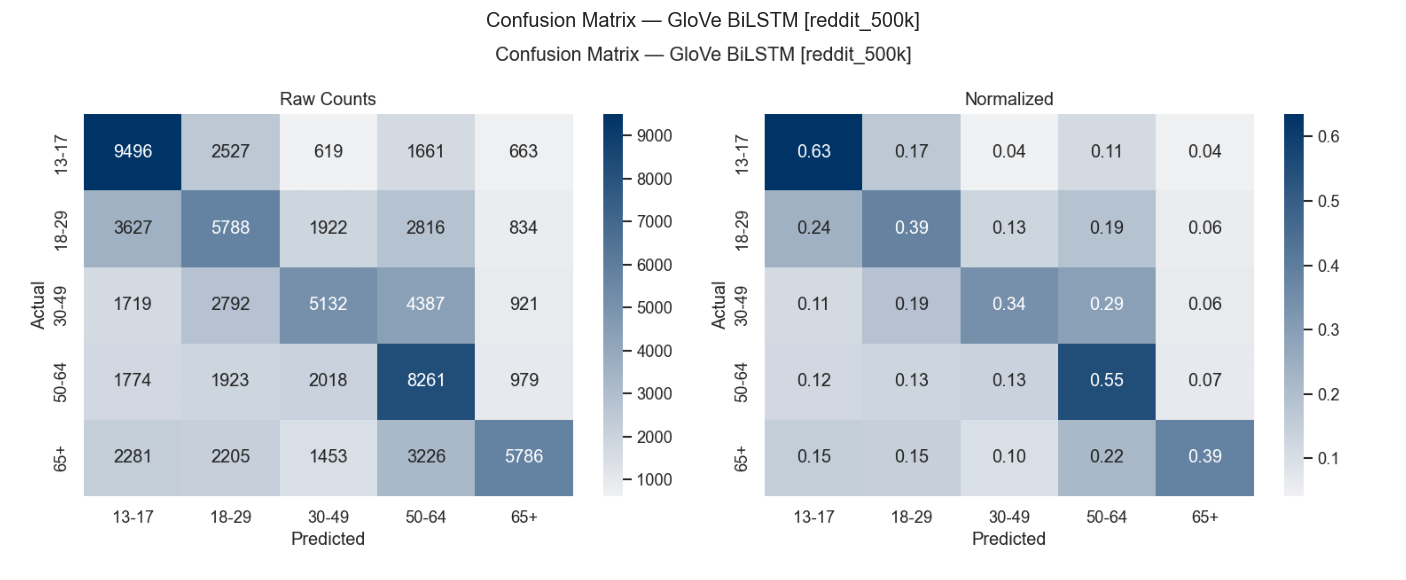

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_bilstm_reddit_500k.png


In [52]:
# ── 7.2 for split_key in reddit_split_keys_dl: ─────────────────────────────────────────
for split_key in reddit_split_keys_dl:
    print()
    print(f"===== GloVe BiLSTM | {split_key} =====")
    split_data = dl_split_data[split_key]

    bilstm_model, lstm_history, val_metrics, test_metrics, bilstm_preds = run_torch_experiment(
        model_label="GloVe BiLSTM",
        family_slug="glove_bilstm",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: BiLSTMAttention(
            embedding_matrix=embedding_matrix,
            num_classes=CFG["num_labels"],
            hidden_dim=CFG["lstm_hidden_dim"],
            num_layers=CFG["lstm_num_layers"],
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe BiLSTM [{split_key}]"
    deep_histories[run_name] = lstm_history
    deep_test_preds[run_name] = bilstm_preds

    deep_curve_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "reddit_500k":
        plot_confusion_matrix_clf(split_data["y_test"], bilstm_preds, run_name, le)


## 7.4 Results


,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,reddit_10k,7000,0.360223
1,GloVe BiLSTM,reddit_100k,69940,0.422327
2,GloVe BiLSTM,reddit_500k,349111,0.457790
3,GloVe CNN,reddit_10k,7000,0.357340
4,GloVe CNN,reddit_100k,69940,0.416675
5,GloVe CNN,reddit_500k,349111,0.449732
6,GloVe MLP,reddit_10k,7000,0.392685
7,GloVe MLP,reddit_100k,69940,0.419155
8,GloVe MLP,reddit_500k,349111,0.443782


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,results_key
0,GloVe BiLSTM,reddit_10k,7000,val,0.364667,0.360223,0.360223,NaN,GloVe BiLSTM [reddit_10k] | val
1,GloVe BiLSTM,reddit_100k,69940,val,0.420270,0.422327,0.422314,NaN,GloVe BiLSTM [reddit_100k] | val
2,GloVe BiLSTM,reddit_500k,349111,val,0.461235,0.457790,0.457775,NaN,GloVe BiLSTM [reddit_500k] | val
3,GloVe CNN,reddit_10k,7000,val,0.355333,0.357340,0.357340,NaN,GloVe CNN [reddit_10k] | val
4,GloVe CNN,reddit_100k,69940,val,0.419202,0.416675,0.416662,NaN,GloVe CNN [reddit_100k] | val
5,GloVe CNN,reddit_500k,349111,val,0.453629,0.449732,0.449719,NaN,GloVe CNN [reddit_500k] | val
6,GloVe MLP,reddit_10k,7000,val,0.395333,0.392685,0.392685,NaN,GloVe MLP [reddit_10k] | val
7,GloVe MLP,reddit_100k,69940,val,0.418868,0.419155,0.419140,NaN,GloVe MLP [reddit_100k] | val
8,GloVe MLP,reddit_500k,349111,val,0.445676,0.443782,0.443758,NaN,GloVe MLP [reddit_500k] | val


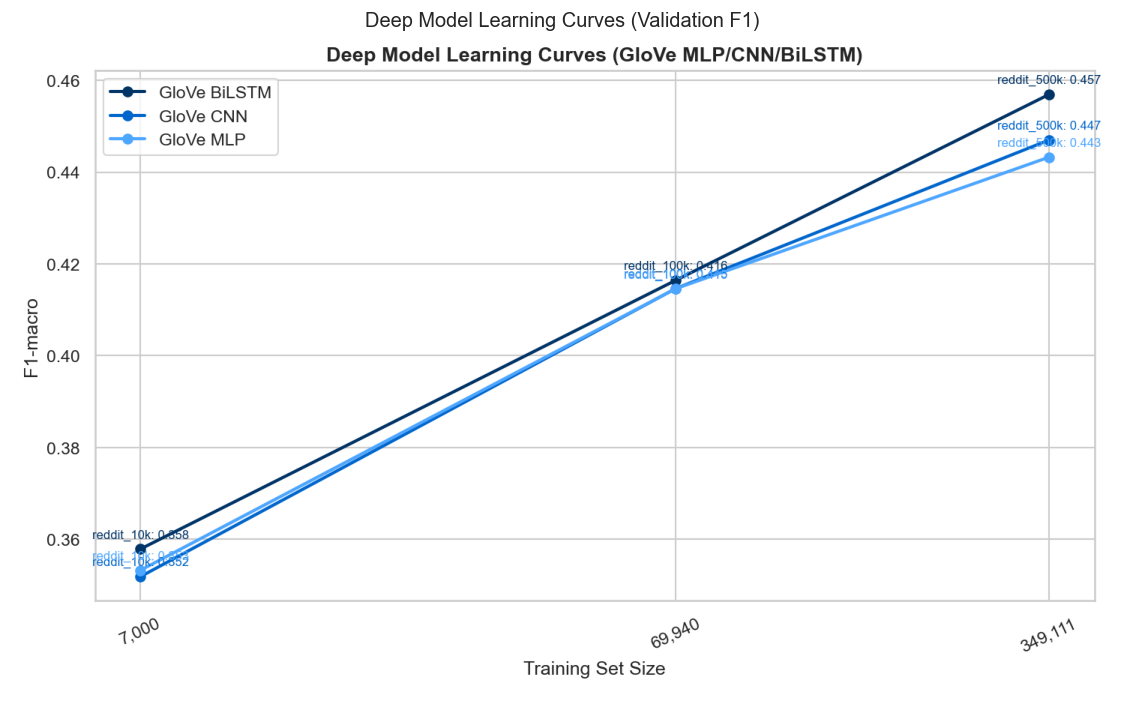

Displayed existing learning curve: outputs/plots/learning_curves/deep_learning_curves_glove_val.png


In [53]:
# ── 7.3 Unified reporting: always rebuild from RESULTS so resumed / partial runs are included. ─────────────────────────────────────────
# Unified reporting: always rebuild from RESULTS so resumed / partial runs are included.
deep_curve_df, deep_eval_df = render_deep_learning_curves_from_results(
    results=RESULTS,
    splits=splits,
    cfg=CFG,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split="val",
    title="Deep Model Learning Curves (Validation F1)",
    save_name="deep_learning_curves_glove_val.png",
)


Loaded csv: outputs/metrics/classical_lc_metrics.csv


,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,reddit_10k,7000,0.360223
1,GloVe BiLSTM,reddit_100k,69940,0.422327
2,GloVe BiLSTM,reddit_500k,349111,0.457790
3,GloVe CNN,reddit_10k,7000,0.357340
4,GloVe CNN,reddit_100k,69940,0.416675
5,GloVe CNN,reddit_500k,349111,0.449732
6,GloVe MLP,reddit_10k,7000,0.392685
7,GloVe MLP,reddit_100k,69940,0.419155
8,GloVe MLP,reddit_500k,349111,0.443782
9,Majority Class,reddit_500k,349111,0.066759


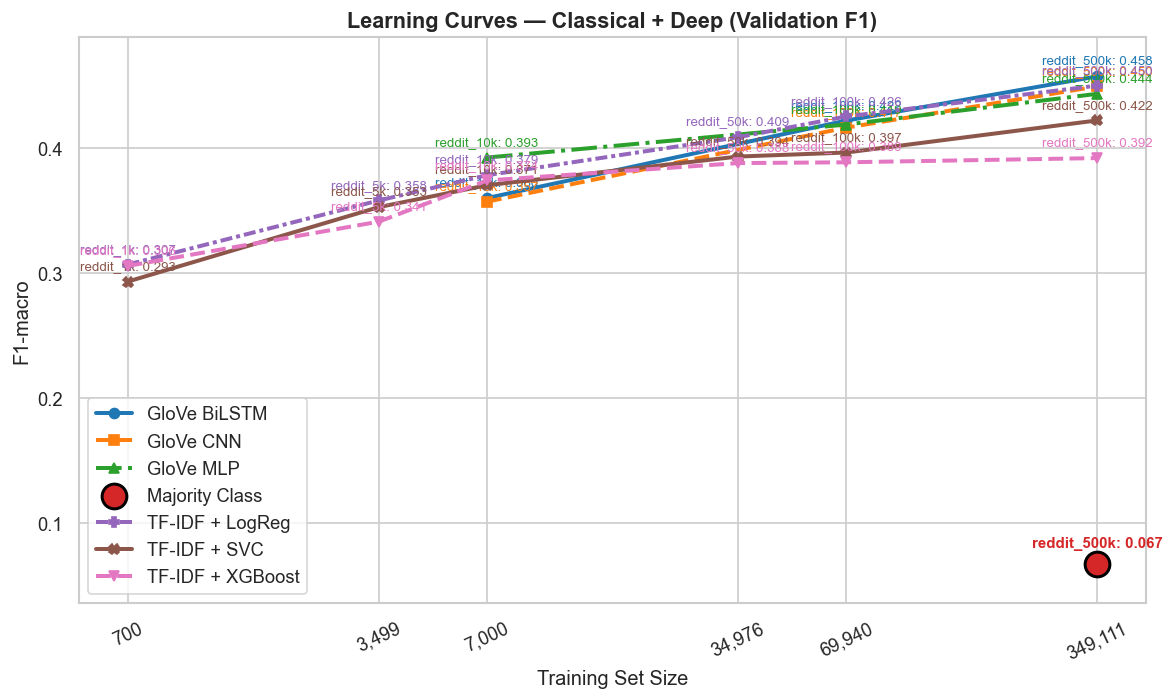

,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,reddit_10k,7000,0.360223
1,GloVe BiLSTM,reddit_100k,69940,0.422327
2,GloVe BiLSTM,reddit_500k,349111,0.457790
3,GloVe CNN,reddit_10k,7000,0.357340
4,GloVe CNN,reddit_100k,69940,0.416675
5,GloVe CNN,reddit_500k,349111,0.449732
6,GloVe MLP,reddit_10k,7000,0.392685
7,GloVe MLP,reddit_100k,69940,0.419155
8,GloVe MLP,reddit_500k,349111,0.443782
9,Majority Class,reddit_500k,349111,0.066759


In [54]:
# ── 7.4 if "deep_curve_df" in globals() and deep_curve_df is not None and not deep_curve_df.empty: ─────────────────────────────────────────
if "deep_curve_df" in globals() and deep_curve_df is not None and not deep_curve_df.empty:
    deep_part = deep_curve_df[["model", "split_key", "train_size", "f1_macro"]].copy()
else:
    raise ValueError("deep_curve_df is empty. Run section 9.4 first.")

classical_part = load_csv_with_fallback(
    CFG["output_paths"]["metrics"] / "classical_lc_metrics.csv",
    CFG["output_dir"] / "classical_lc_metrics.csv",
)
classical_part = classical_part[["model", "split_key", "train_size", "f1_macro"]].copy()

combined_curve_df = (
    pd.concat([classical_part, deep_part], ignore_index=True)
    .drop_duplicates(subset=["model", "split_key"], keep="last")
    .sort_values(["model", "train_size"])
    .reset_index(drop=True)
)

display(combined_curve_df)

plot_learning_curve_from_metrics(
    combined_curve_df,
    title="Learning Curves — Classical + Deep (Validation F1)",
    save_path=CFG["output_paths"]["plots_learning"] / "learning_curves_unified_all_models.png",
    force_replot=True,
)


---
<a id="section-11-transformer-fine-tuning"></a>
# SECTION 11 — Transformer Fine-Tuning

## 11.1 Preparation & Architecture

- Uses HuggingFace `Trainer` with early stopping on `f1_macro`.  
- Input: `text_raw` (minimally cleaned) — the subword tokenizer handles the rest.

In [55]:
# ── 11.1
TRANSFORMER_RUNS = {}
BASE_500K_BUNDLE = build_transformer_bundle_from_split("reddit_500k")
DATA_1000K_PATH = CFG["data_dir"] / "abcde" / "reddit" / "other" / "reddit_processed_200k_per_class.parquet"

**Architecure**:
- Fine-tunes pretrained encoder backbones (`distilbert-base-uncased`, `roberta-base`) with the shared transformer training pipeline.

In [56]:
# ── 11.2 TBA


## 11.2 Training

### 11.2.1 DistilBERT_500k

In [57]:
# ── 11.3 print("\n### 10.4 DistilBERT_500k ###") ─────────────────────────────────────────
print("\n### 10.4 DistilBERT_500k ###")

TRANSFORMER_RUNS["DistilBERT_500k"] = run_transformer_experiment(
    display_name="DistilBERT_500k",
    family_slug="distilbert",
    size_tag="500k",
    model_name="distilbert-base-uncased",
    data_bundle=BASE_500K_BUNDLE,
    batch_size=CFG["batch_size"],
    epochs=CFG["epochs"],
    lr=CFG["lr"],
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=1,
    early_stopping_patience=2,
    eval_mode="epoch",
    legacy_best_dirs=[
        CFG["model_dir"] / "transformer_best",
    ],
    legacy_checkpoint_dirs=[
        CFG["model_dir"] / "transformer",
    ],
)


### 10.4 DistilBERT_500k ###
DistilBERT_500k: loaded cached predictions -> val_preds_20260304_161701.npy, test_preds_20260304_161701.npy
DistilBERT_500k: loaded cached metrics -> skip evaluation (models/distilbert_reddit_500k_20260303_022503/runs/metrics_latest.json)
DistilBERT_500k | VAL metrics: {'accuracy': 0.5014169228712739, 'f1_macro': 0.500556561904604, 'f1_weighted': 0.5005451453504786}
DistilBERT_500k | TEST metrics: {'accuracy': 0.5007619302232322, 'f1_macro': 0.4991819498556428, 'f1_weighted': 0.499172504643608}
Final validation F1 (macro) [DistilBERT_500k]: 0.5006 (cached)


### 11.2.2 RoBERTa_500k


In [58]:
# ── 11.4 Note: RoBERTa_500k can be marginally better, but usually not worth the extra compute cost. ─────────────────────────────────────────
# Note: RoBERTa_500k can be marginally better, but usually not worth the extra compute cost.
print("\n### 10.5 RoBERTa_500k ###")

TRANSFORMER_RUNS["RoBERTa_500k"] = run_transformer_experiment(
    display_name="RoBERTa_500k",
    family_slug="roberta_base",
    size_tag="500k",
    model_name="roberta-base",
    data_bundle=BASE_500K_BUNDLE,
    batch_size=8,
    epochs=3,
    lr=2e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=2,
    early_stopping_patience=2,
    eval_mode="epoch",
    legacy_best_dirs=[
        CFG["model_dir"] / "roberta_base_500k_best",
    ],
    legacy_checkpoint_dirs=[
        CFG["model_dir"] / "roberta_base_500k",
    ],
)


### 10.5 RoBERTa_500k ###
RoBERTa_500k: loaded cached predictions -> val_preds_20260304_164557.npy, test_preds_20260304_164557.npy
RoBERTa_500k: loaded cached metrics -> skip evaluation (models/roberta_base_reddit_500k_20260304_115835/runs/metrics_latest.json)
RoBERTa_500k | VAL metrics: {'accuracy': 0.5176981686940249, 'f1_macro': 0.5170770990752951, 'f1_weighted': 0.517067918567647}
RoBERTa_500k | TEST metrics: {'accuracy': 0.5176580671033284, 'f1_macro': 0.5170145939218276, 'f1_weighted': 0.5170052860730421}
Final validation F1 (macro) [RoBERTa_500k]: 0.5171 (cached)


### 11.2.3 DistilBERT_1000k

In [59]:
# ── 11.5 print("\n### 10.6 DistilBERT_1000k (final) ###") ─────────────────────────────────────────
print("\n### 10.6 DistilBERT_1000k (final) ###")

bundle_1000k = build_transformer_bundle_from_parquet(DATA_1000K_PATH, drop_duplicates=False)

legacy_1000_ckpt_dirs = sorted(CFG["model_dir"].glob("distilbert_age_1000_*"))

TRANSFORMER_RUNS["DistilBERT_1000k"] = run_transformer_experiment(
    display_name="DistilBERT_1000k",
    family_slug="distilbert",
    size_tag="1000k",
    model_name="distilbert-base-uncased",
    data_bundle=bundle_1000k,
    batch_size=8,
    epochs=3,
    lr=2e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=4,
    early_stopping_patience=3,
    eval_mode="steps",
    eval_steps=10_000,
    save_steps=10_000,
    legacy_best_dirs=[
        CFG["model_dir"] / "transformer_best_1000",
    ],
    legacy_checkpoint_dirs=legacy_1000_ckpt_dirs,
)

# Final/default transformer artefacts for downstream cells
FINAL_TRANSFORMER_NAME = "DistilBERT_1000k"
FINAL_TRANSFORMER_RUN = TRANSFORMER_RUNS[FINAL_TRANSFORMER_NAME]
TRANSFORMER_FINAL_BEST_PATH = FINAL_TRANSFORMER_RUN["best_dir"]

trf_test_preds = FINAL_TRANSFORMER_RUN["test_preds"]
trf_val_preds = FINAL_TRANSFORMER_RUN["val_preds"]
trf_y_test = FINAL_TRANSFORMER_RUN["y_test"]
trf_df_test = FINAL_TRANSFORMER_RUN["df_test"]

print(f"Final transformer: {FINAL_TRANSFORMER_NAME} -> {TRANSFORMER_FINAL_BEST_PATH}")



### 10.6 DistilBERT_1000k (final) ###
reddit_processed_200k_per_class.parquet: train=700,000 | val=150,000 | test=150,000
DistilBERT_1000k: loaded cached predictions -> val_preds_20260304_171120.npy, test_preds_20260304_171120.npy
DistilBERT_1000k: loaded cached metrics -> skip evaluation (models/distilbert_reddit_1000k_20260223_233842/runs/metrics_latest.json)
DistilBERT_1000k | VAL metrics: {'accuracy': 0.5918066666666667, 'f1_macro': 0.5883555803728207, 'f1_weighted': 0.5883555803728207}
DistilBERT_1000k | TEST metrics: {'accuracy': 0.5370933333333333, 'f1_macro': 0.5350899183439646, 'f1_weighted': 0.5350899183439645}
Final validation F1 (macro) [DistilBERT_1000k]: 0.5884 (cached)
Final transformer: DistilBERT_1000k -> models/distilbert_reddit_1000k_20260223_233842/best_model


## 11.3 Results

In [60]:
# ── 11.6 transformer_summary_rows = [] ─────────────────────────────────────────
transformer_summary_rows = []
for name in ["DistilBERT_500k", "RoBERTa_500k", "DistilBERT_1000k"]:
    run = TRANSFORMER_RUNS[name]
    transformer_summary_rows.append({
        "experiment": name,
        "val_f1_macro": float(run["val_metrics"]["f1_macro"]),
        "test_f1_macro": float(run["test_metrics"]["f1_macro"]),
        "best_model": str(run["best_dir"]),
    })

transformer_summary_df = pd.DataFrame(transformer_summary_rows).sort_values("val_f1_macro", ascending=False)
display(transformer_summary_df)

for row in transformer_summary_df.itertuples(index=False):
    RESULTS[f"LC | {row.experiment} | reddit_{'1000k' if '1000' in row.experiment else '500k'}"] = {
        "f1_macro": float(row.val_f1_macro)
    }


,experiment,val_f1_macro,test_f1_macro,best_model
2,DistilBERT_1000k,0.588356,0.535090,models/distilbert_reddit_1000k_20260223_233842...
1,RoBERTa_500k,0.517077,0.517015,models/roberta_base_reddit_500k_20260304_11583...
0,DistilBERT_500k,0.500557,0.499182,models/distilbert_reddit_500k_20260303_022503/...


---
<a id="section-12-model-comparison-results-table"></a>
# SECTION 12 — Model Comparison & Results Table


In [61]:
# ── 12.1 print_results_table() ─────────────────────────────────────────
print_results_table()


Model                                              accuracy      f1_macro   f1_weighted
TF-IDF + LogReg [reddit_1k] | val                    0.3067        0.3069        0.3069
TF-IDF + LogReg [reddit_1k] | test                   0.2933        0.2893        0.2893
TF-IDF + SVC [reddit_1k] | val                       0.2933        0.2933        0.2933
TF-IDF + SVC [reddit_1k] | test                      0.2933        0.2912        0.2912
TF-IDF + XGBoost [reddit_1k] | val                   0.3133        0.3058        0.3058
TF-IDF + XGBoost [reddit_1k] | test                  0.2667        0.2676        0.2676
TF-IDF + LogReg [reddit_5k] | val                    0.3560        0.3583        0.3583
TF-IDF + LogReg [reddit_5k] | test                   0.3267        0.3280        0.3280
TF-IDF + SVC [reddit_5k] | val                       0.3533        0.3530        0.3530
TF-IDF + SVC [reddit_5k] | test                      0.3280        0.3284        0.3284
TF-IDF + XGBoost [reddit_5k] | 

In [62]:
# ── 12.2 df_results = ( ─────────────────────────────────────────
df_results = (
    pd.DataFrame(RESULTS)
    .T
    .rename_axis("Model | Split")
    .sort_values("f1_macro", ascending=False)
)
display(df_results.round(4))

df_results.to_csv(CFG["output_paths"]["metrics"] / f"results_{CFG['task']}.csv")
print("Results saved.")


,accuracy,f1_macro,f1_weighted
Model | Split,,,
LC | DistilBERT_1000k | reddit_1000k,NaN,0.5884,NaN
DistilBERT_1000k | val,0.5918,0.5884,0.5884
DistilBERT_1000k | test,0.5371,0.5351,0.5351
LC | RoBERTa_500k | reddit_500k,NaN,0.5171,NaN
RoBERTa_500k | val,0.5177,0.5171,0.5171
...,...,...,...
TF-IDF + LogReg [reddit_1k] | test,0.2933,0.2893,0.2893
TF-IDF + XGBoost [reddit_1k] | test,0.2667,0.2676,0.2676
LC | Majority Class | reddit_500k,NaN,0.0668,NaN


Results saved.


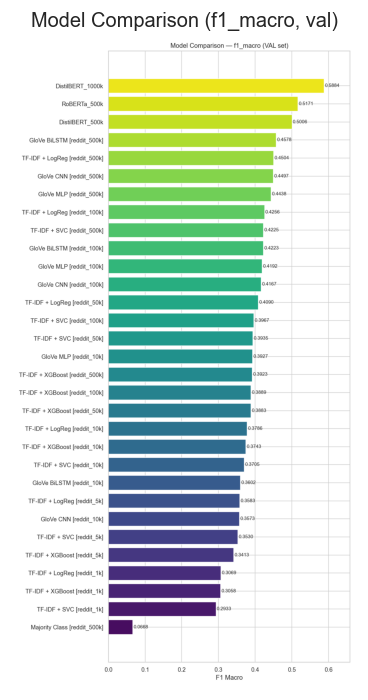

Displayed existing plot: outputs/plots/comparisons/comparison_f1_macro_val.png


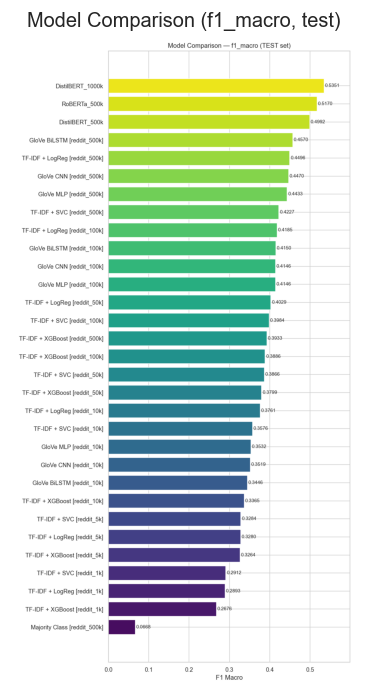

Displayed existing plot: outputs/plots/comparisons/comparison_f1_macro_test.png


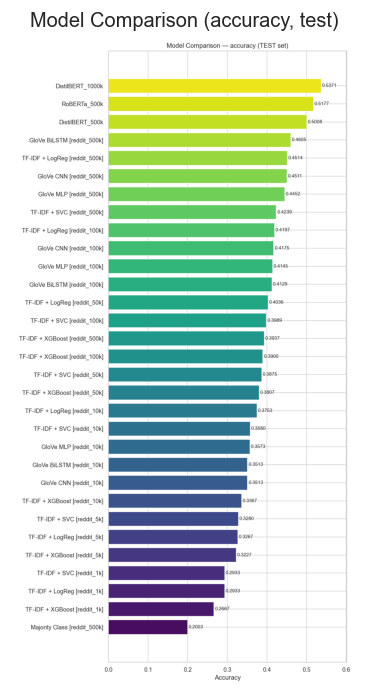

Displayed existing plot: outputs/plots/comparisons/comparison_accuracy_test.png


In [63]:
# ── 12.3 def plot_model_comparison(results: dict, metric: str = "f1_macro", ─────────────────────────────────────────
def plot_model_comparison(results: dict, metric: str = "f1_macro",
                          split: str = "test"):
    """
    Horizontal bar chart comparing all models on `metric` for the given `split`.

    Parameters
    ----------
    results : RESULTS dict
    metric  : column to plot (e.g. "f1_macro", "accuracy")
    split   : "test" or "val" — filters RESULTS entries
    """
    filtered = {
        k.replace(f" | {split}", ""): v[metric]
        for k, v in results.items()
        if split in k and metric in v
    }
    if not filtered:
        print(f"No results for split='{split}', metric='{metric}'.")
        return

    out_path = CFG["output_paths"]["plots_comparison"] / f"comparison_{metric}_{split}.png"
    if display_saved_plot(out_path, title=f"Model Comparison ({metric}, {split})"):
        print(f"Displayed existing plot: {out_path}")
        return

    names = list(filtered.keys())
    values = list(filtered.values())
    order = np.argsort(values)

    fig, ax = plt.subplots(figsize=(9, max(4, len(names) * 0.55)))
    bars = ax.barh(
        [names[i] for i in order],
        [values[i] for i in order],
        color=sns.color_palette("viridis", len(names))
    )
    for bar, val in zip(bars, [values[i] for i in order]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_title(f"Model Comparison — {metric} ({split.upper()} set)")
    ax.set_xlim(0, min(1.05, max(values) * 1.12))
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()


plot_model_comparison(RESULTS, metric="f1_macro", split="val")
plot_model_comparison(RESULTS, metric="f1_macro", split="test")
plot_model_comparison(RESULTS, metric="accuracy", split="test")


In [64]:
# ── 12.4 def error_analysis(df_split: pd.DataFrame, y_true, y_pred, ─────────────────────────────────────────
def error_analysis(df_split: pd.DataFrame, y_true, y_pred,
                   label_encoder=None, n: int = 10) -> pd.DataFrame:
    """
    Returns a DataFrame of the top-n misclassified samples.

    Parameters
    ----------
    df_split      : DataFrame for the relevant split (e.g. df_test)
    y_true, y_pred: encoded labels
    label_encoder : to decode label names
    n             : number of examples to display
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"y_true and y_pred length mismatch: {len(y_true)} vs {len(y_pred)}")

    err_mask = y_true != y_pred
    df_err = df_split[err_mask].copy()
    df_err["y_true"] = y_true[err_mask]
    df_err["y_pred"] = y_pred[err_mask]

    if label_encoder is not None:
        if hasattr(label_encoder, "inverse_transform"):
            df_err["true_label"] = label_encoder.inverse_transform(df_err["y_true"])
            df_err["pred_label"] = label_encoder.inverse_transform(df_err["y_pred"])
        elif hasattr(label_encoder, "classes_"):
            classes = np.asarray(label_encoder.classes_)

            def decode_ids(arr):
                arr = np.asarray(arr, dtype=np.int64)
                return np.array([classes[i] if 0 <= i < len(classes) else str(i) for i in arr])

            df_err["true_label"] = decode_ids(df_err["y_true"])
            df_err["pred_label"] = decode_ids(df_err["y_pred"])
        else:
            df_err["true_label"] = df_err["y_true"]
            df_err["pred_label"] = df_err["y_pred"]

        cols = [CFG["text_col"], "true_label", "pred_label"]
    else:
        cols = [CFG["text_col"], "y_true", "y_pred"]

    return df_err[cols].head(n)


print(f"=== Error Analysis — {globals().get('FINAL_TRANSFORMER_NAME', 'Transformer')} ===")
error_df = error_analysis(
    globals().get("trf_df_test", df_test),
    globals().get("trf_y_test", y_test),
    globals().get("trf_test_preds", np.asarray([])),
    le,
    n=10,
)
display(error_df)


=== Error Analysis — DistilBERT_1000k ===


,text,true_label,pred_label
2,Am I the only Russian kid at this school?. I f...,18-29,13-17
3,For Those About To Mod: WE SALUTE YOU!. The go...,50-64,65+
4,"Emojis are becoming punctuation marks. See, I ...",18-29,13-17
5,Chevron across from Highland Baptist at night....,65+,50-64
8,Cant go to treatment I'll just keep bingeing u...,30-49,18-29
9,Will Jackass Forever.5 be released on blu-ray?...,18-29,13-17
14,Should I get a 2080 Ti even if I don't have a ...,18-29,13-17
17,How to track CTR for keywords?. 2020 is the ye...,18-29,30-49
18,Need help from my BOTL! Looking for some hard ...,65+,18-29
21,RDO dead eye is not working. I am at level 23 ...,30-49,50-64


---
<a id="section-13-saving-logging-final-report"></a>
# SECTION 13 — Saving, Logging & Final Report


In [65]:
# ── 13.1 def save_artefacts(): ─────────────────────────────────────────
def save_artefacts():
    """Saves CFG, RESULTS, label encoder and vocab to disk."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

    metrics_dir = CFG["output_paths"]["metrics"]
    metrics_dir.mkdir(parents=True, exist_ok=True)

    cfg_serializable = {k: str(v) if isinstance(v, Path) else v
                        for k, v in CFG.items()}
    with open(metrics_dir / f"cfg_{timestamp}.json", "w") as f:
        json.dump(cfg_serializable, f, indent=2, default=str)

    with open(metrics_dir / f"results_{timestamp}.json", "w") as f:
        json.dump(RESULTS, f, indent=2)

    shared_model_dir = CFG["model_dir"] / "shared"
    shared_model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(le, shared_model_dir / "label_encoder.pkl")
    joblib.dump(vocab, shared_model_dir / "vocab.pkl")

    print(f"Artefacts saved  ->  {metrics_dir}  |  {shared_model_dir}")

save_artefacts()


Artefacts saved  ->  outputs/metrics  |  models/shared


In [66]:
# ── 13.2 pip install wandb ─────────────────────────────────────────
# pip install wandb

# import wandb
# wandb.init(
#     project=CFG["task"],
#     config=CFG,
#     name=f"run_{datetime.now().strftime('%m%d_%H%M')}"
# )
# Then set report_to="wandb" in TrainingArguments.


In [67]:
# ── 13.3 Before claiming Model A > Model B, verify with McNemar's test. ─────────────────────────────────────────
# Before claiming Model A > Model B, verify with McNemar's test.
# p-value > 0.05 → difference is NOT statistically significant.

# from statsmodels.stats.contingency_tables import mcnemar

# correct_a = (bilstm_preds   == y_test)
# correct_b = (trf_test_preds == y_test)
# table = np.array([
#     [(correct_a & correct_b).sum(),  (~correct_a & correct_b).sum()],
#     [(correct_a & ~correct_b).sum(), (~correct_a & ~correct_b).sum()]
# ])
# result = mcnemar(table, exact=False)
# print(f"McNemar p-value: {result.pvalue:.4f}")
# print(f"Significant difference: {result.pvalue < 0.05}")


In [68]:
# ── 13.4 Useful when one class is heavily under-represented (e.g. abuse class). ─────────────────────────────────────────
# Useful when one class is heavily under-represented (e.g. abuse class).
# pip install transformers sentencepiece

# from transformers import MarianMTModel, MarianTokenizer

# def back_translate(texts, src_lang="Helsinki-NLP/opus-mt-en-fr",
#                           tgt_lang="Helsinki-NLP/opus-mt-fr-en"):
#     tok_fwd  = MarianTokenizer.from_pretrained(src_lang)
#     mdl_fwd  = MarianMTModel.from_pretrained(src_lang)
#     fr_ids   = mdl_fwd.generate(**tok_fwd(texts, return_tensors="pt", padding=True, truncation=True))
#     fr_texts = tok_fwd.batch_decode(fr_ids, skip_special_tokens=True)
#     tok_bwd  = MarianTokenizer.from_pretrained(tgt_lang)
#     mdl_bwd  = MarianMTModel.from_pretrained(tgt_lang)
#     en_ids   = mdl_bwd.generate(**tok_bwd(fr_texts, return_tensors="pt", padding=True, truncation=True))
#     return tok_bwd.batch_decode(en_ids, skip_special_tokens=True)


In [69]:
# ── 13.5 fold_scores = [] ─────────────────────────────────────────

# fold_scores = []
# for fold, (train_idx, val_idx) in enumerate(cv.split(df, df["label_enc"])):
#     print(f"\n── Fold {fold+1}/{CFG['cv_folds']} ──")
#     df_f_train = df.iloc[train_idx].reset_index(drop=True)
#     df_f_val   = df.iloc[val_idx].reset_index(drop=True)
#     # ... rebuild sequences, loaders, reinitialise model, train, evaluate ...
#     fold_scores.append(fold_f1)
# print(f"CV F1-macro: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")


In [70]:
# ── 13.6 dummy_input = torch.zeros(1, CFG["max_seq_len"], dtype=torch.long).to(CFG["device"]) ─────────────────────────────────────────

# dummy_input = torch.zeros(1, CFG["max_seq_len"], dtype=torch.long).to(CFG["device"])
# cnn_model.eval()
# torch.onnx.export(
#     cnn_model, dummy_input,
#     CFG["model_dir"] / "TextCNN.onnx",
#     input_names=["input_ids"],
#     output_names=["logits"],
#     opset_version=14,
#     dynamic_axes={"input_ids": {0: "batch_size"}}
# )
# print("ONNX model saved.")


In [71]:
# ── 13.7 TESTING BEST MODEL ─────────────────────────────────────────
# TESTING BEST MODEL

MODEL_PATH = str(globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best"))

# Load once
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device(CFG["device"])
model.to(device)
model.eval()


def _decode_label(pred_id: int, label_encoder=None, model_obj=None) -> str:
    if label_encoder is not None:
        if hasattr(label_encoder, "inverse_transform"):
            return str(label_encoder.inverse_transform([pred_id])[0])
        if hasattr(label_encoder, "classes_"):
            classes = np.asarray(label_encoder.classes_)
            if 0 <= pred_id < len(classes):
                return str(classes[pred_id])

    if model_obj is not None and hasattr(model_obj, "config"):
        id2label = getattr(model_obj.config, "id2label", None)
        if isinstance(id2label, dict):
            key = pred_id if pred_id in id2label else str(pred_id)
            if key in id2label:
                return str(id2label[key])

    return str(pred_id)


@torch.no_grad()
def predict_one(text: str):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=CFG.get("max_len", 256)
    ).to(device)

    outputs = model(**inputs)
    logits = outputs.logits

    probs = torch.softmax(logits, dim=-1)
    conf, pred_id = torch.max(probs, dim=-1)

    pred_id = int(pred_id.item())
    confidence = float(conf.item())

    pred_label = _decode_label(pred_id, globals().get("le", None), model)
    return pred_label, confidence


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [72]:
# ── 13.8 Example texts for quick manual model check ─────────────────────────────────────────
# Example texts for quick manual model check
example_texts = [
    "I just finished my homework and now I'm playing video games with my classmates.",
    "I moved to a new city for university and I am learning to manage my budget.",
    "I started my first full-time job this year and I am building my career step by step.",
    "My partner and I are planning to buy our first apartment and thinking about long-term finances.",
    "I have two school-age kids, so most evenings are homework, dinner, and bedtime routines.",
    "After many years at work, I am focusing more on health, family time, and a calmer lifestyle.",
    "I recently retired and now I spend mornings gardening and afternoons reading history books.",
]

for i, text in enumerate(example_texts, start=1):
    label, conf = predict_one(text)
    print(f"{i}. Text: {text}")
    print(f"   Prediction: {label} | Confidence: {conf:.4f}")
    print("-" * 100)


1. Text: I just finished my homework and now I'm playing video games with my classmates.
   Prediction: 13-17 | Confidence: 0.7462
----------------------------------------------------------------------------------------------------
2. Text: I moved to a new city for university and I am learning to manage my budget.
   Prediction: 18-29 | Confidence: 0.6018
----------------------------------------------------------------------------------------------------
3. Text: I started my first full-time job this year and I am building my career step by step.
   Prediction: 18-29 | Confidence: 0.5402
----------------------------------------------------------------------------------------------------
4. Text: My partner and I are planning to buy our first apartment and thinking about long-term finances.
   Prediction: 18-29 | Confidence: 0.4612
----------------------------------------------------------------------------------------------------
5. Text: I have two school-age kids, so most evenings a

In [ ]:
# ── 13.9
